# 注意事項

#### 重啟工作階段需要再次設置環境
#### 資料切分有兩個版本 (Opt2好像比較差 也可以試看看)
#### 同時使用Sunlight和日射量好像比較好 (可以試看看只用其中一個)
#### 有/沒 做feature normalizaiton 結果差不多
#### enc_in, dec_in, cout 是 feature的數目, feature的數目改變需要調整, 只用Sunlight或日射量要改成5

#### label_len 只對有用decoder模型有作用 (需小於pred_len)
#### pred_len = 48, 不用更改
#### Stride ratio 越大訓練越快, loss好像差不多
#### 更改seed 在 Training block下方
#### Performace 參考
#### Val loss: 100000 -> 上傳 1154302.36
#### Val loss: 0.3886 -> 上傳 1197663.5
#### 最後要上傳的test loader大概要跑25-35分鐘
#### 如果有更改seq_len, label_len, pred_len 或更改 scale 需要再重跑
#### NA ratio, Stride ratio 在參數調整區塊下方data_provider函數裡
#### scale 在data_provider函數的區塊更改
#### 如果train的時候沒用sunlight或是日射量 要在class MicroClimate_Test drop掉
#### MicroClimate_Test 在 Final Prediction 區塊
<br>


#### 重要參數：
#### 參數調整區塊
#### seq_len, label_len ; enc_in, dec_in, cout
#### d_model, n_heads, e_layers, d_layers, d_ff
#### optimizer, model
#### train_epochs, patience(Early Stopping), learning_rate, augmentation, batch_size
<br>

#### data_provider函數的區塊(參數調整區塊下方)
#### scale: 控制是否做normalization
#### Stride ratio


In [ ]:
# 以下程式碼引用自以下開源專案：
# 1. Time-Series-Library (THUML @ Tsinghua University)
#    原始專案網址: https://github.com/thuml/Time-Series-Library
#    授權: MIT License
#
# 2. SAM (Sharpness-Aware Minimization) by davda54
#    原始專案網址: https://github.com/davda54/sam
#    授權: MIT License
#
# 3. Ranger21 - integrating the latest deep learning components into a single optimizer by lessw2020
#    原始專案網址: https://github.com/lessw2020/Ranger21
#    授權: Apache License 2.0

# 環境設定 (Colab)

In [ ]:
# 環境設定
!wget -c https://repo.anaconda.com/miniconda/Miniconda3-py38_4.11.0-Linux-x86_64.sh
!ls
!chmod +x Miniconda3-py38_4.11.0-Linux-x86_64.sh

In [ ]:
# 環境設定
%env PYTHONPATH=
!bash ./Miniconda3-py38_4.11.0-Linux-x86_64.sh -b -f -p /usr/local

In [ ]:
# 環境設定
import sys
_ = (sys.path.append("/usr/local/lib/python3.8/site-packages"))
_ = (sys.path.append("/usr/local/lib/python3.8/dist-packages"))

In [ ]:
# 環境設定
!which conda
!conda --version
!which python
!python -V

In [ ]:
# 安裝套件
!pip install einops==0.8.0 local-attention==1.9.14 matplotlib==3.7.0 numpy==1.23.5 \
utils pandas==1.5.3 patool==1.12 reformer-pytorch==1.4.4 scikit-learn==1.2.2 \
scipy==1.10.1 \
sktime==0.16.1 \
sympy==1.11.1 \
tsaug \
torch==1.7.1+cu110 torchvision==0.8.2+cu110 torchaudio==0.7.2 -f https://download.pytorch.org/whl/torch_stable.html  \
tqdm==4.64.1\
openfe \
pickle

In [ ]:
!git clone https://github.com/thuml/Time-Series-Library.git

In [ ]:
!git clone https://github.com/davda54/sam.git

In [ ]:
!python -m pip install git+https://github.com/lessw2020/Ranger21.git

# 資料處理

#### 以迴歸預測 Sunlight > 11778.2 的值
#### 同地點同分鐘資料 留任一筆  
#### 10分鐘平均為一筆資料
#### 去除風速, 地點
#### 去除7a.m.-5p.m.以外的時間
#### 空缺時間點補NA
#### 外部資料串接 (新增一個solar irradiance的col)

In [ ]:
!pip install tsaug

In [ ]:
%matplotlib inline
import os
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import time
import matplotlib.pyplot as plt
import tsaug
from tsaug.visualization import plot

# 外部日射量資料
if not os.path.exists('/content/solar'):
   os.mkdir('/content/solar')

In [ ]:
# Data directory
if not os.path.exists('/content/MicroClimate'):
   os.mkdir('/content/MicroClimate')
os.chdir('/content/MicroClimate')

In [ ]:
# regress Sunlight(Lux) to Power(mW)
def sunlight_reg_coef():
    for i in range(1,18):
        data = pd.read_csv(f"L{i}_Train.csv")
        if i in [2,4,7,8,9,10,12]:
              d_ = pd.read_csv(f"L{i}_Train_2.csv")
              data = pd.concat([data, d_], ignore_index =True)
        if i==1:
           data_sun_pow = data[['Sunlight(Lux)','Power(mW)']]
        else:
           data_sun_pow = pd.concat([data_sun_pow,data[['Sunlight(Lux)','Power(mW)']]],ignore_index=True)
    data_sun_pow = data_sun_pow[data_sun_pow['Sunlight(Lux)'] < 117758.2]

    model = LinearRegression()
    model.fit(data_sun_pow['Sunlight(Lux)'].values.reshape(-1,1) , data_sun_pow['Power(mW)'].values)

    return model.coef_

# tool func
def seq_sum(sequence):
    new_seq =[0]*len(sequence)
    new_seq[0] = sequence[0]
    for s in range(len(sequence)-1):
        new_seq[s+1] = new_seq[s] + sequence[s+1]
    return new_seq

In [ ]:
# Data preprocess


########
# Default option: 每個地點前面80%是train 後面19.9%是valid 最後0.1% test
#                 將所有地點資料依照不同set合併起來
######

# 不同地點有多少資料在各個set
Boundary_points_train = []
Boundary_points_valid = []
Boundary_points_test = []

sun_coef = sunlight_reg_coef()[0]

for i in range(1,18):
    data = pd.read_csv(f"L{i}_Train.csv")
    if i in [2,4,7,8,9,10,12]:
       d_ = pd.read_csv(f"L{i}_Train_2.csv")
       data = pd.concat([data, d_], ignore_index =True)

    data = data.drop('WindSpeed(m/s)', axis =1) # drop windspeed
    data = data.drop('LocationCode', axis =1) # drop location

    # scaling to min = 117758.2 (min-max ratio)
    if len(data[data["Sunlight(Lux)"] == 117758.2]) > 0:
       transformed_sun = (data[data["Sunlight(Lux)"] == 117758.2]['Power(mW)'] / sun_coef).values
       data_sun_estimate =  117758.2*(1+ (transformed_sun -min(transformed_sun)) / (max(transformed_sun)-min(transformed_sun)))
       data.loc[data["Sunlight(Lux)"] == 117758.2 , 'Sunlight(Lux)']  = data_sun_estimate

    # time setting
    data['DateTime'] = pd.to_datetime(data['DateTime'])
    data['DateTime'] = data['DateTime'].dt.strftime("%Y-%m-%d %H:%M")
    data = data.set_index('DateTime')
    data.index = pd.to_datetime(data.index)
    data = data[~data.index.duplicated()]
    data = data.between_time("07:00","16:59")

    # train / valid / test split : 0.8, 0.19, 0.01
    num_train = int(len(data) * 0.8)
    num_test = int(len(data) * 0.01)
    num_vali = len(data) - num_train - num_test
    data_train = data[0:num_train]
    data_vali = data[num_train:num_train+num_vali]
    data_test = data[num_train+num_vali:]

    for sets in ["train", "valid", "test"]:
        if sets == "train":
           d_ = data_train
        elif sets == "valid":
           d_ = data_vali
        else:  d_ = data_test
        idx = pd.date_range(min(d_.index), max(d_.index),freq='min')
        d_ = d_.reindex(idx, fill_value=0)    # 補0
        d_ = d_.between_time("07:00","16:59") # 留下 7:00 - 16:59

        # 取10分鐘平均 缺多於3筆記為NA
        for k in range(int(len(d_)/10)):
            count = 0
            mean = d_.iloc[k*10:k*10+10,:].mean().values
            for j in range(10):
                if (d_.iloc[k*10+j:k*10+j+1,:].values == np.zeros(5)).all():
                   count = count + 1
            if count < 4 :
                   d_.iloc[k*10:k*10+1,:] =  mean * 10 / (10-count)
            else:
                   d_.iloc[k*10:k*10+1,:] =  np.NaN
            d_.iloc[k*10+1:k*10+10, :] = np.zeros((9,5))
        d_ = d_[:int(len(d_)/10)*10]
        d_ = d_[d_['Pressure(hpa)']!=0]
        if sets == "train":
           Boundary_points_train.append(len(d_))
           if i == 1:
              data_train_f = d_
           else:  data_train_f = pd.concat([data_train_f, d_])
        elif sets == "valid":
           Boundary_points_valid.append(len(d_))
           if i == 1:
              data_valid_f = d_
           else:  data_valid_f = pd.concat([data_valid_f, d_])
        else:
             Boundary_points_test.append(len(d_))
             if i == 1:
                data_test_f = d_
             else:  data_test_f = pd.concat([data_test_f, d_])

Boundary_points_train = seq_sum(Boundary_points_train)
Boundary_points_valid = seq_sum(Boundary_points_valid)
Boundary_points_test = seq_sum(Boundary_points_test)

In [ ]:
# Opt 2: 結果好像較差
# 對每個地點 按照月份切分資料  1月 前80%為train 中19.9為valid 後0.1為test 2月 前80%為train 中19.9為valid 後0.1為test ... ...
# 每個月都有資料

"""
# 記錄月份轉換點
Boundary_points_train = []
Boundary_points_valid = []
Boundary_points_test = []

sun_coef = sunlight_reg_coef()[0]

data_train_f = pd.DataFrame({'A':[], 'B':[], 'C':[], 'D':[], 'E':[]})
data_valid_f = pd.DataFrame({'A':[], 'B':[], 'C':[], 'D':[], 'E':[]})
data_test_f = pd.DataFrame({'A':[], 'B':[], 'C':[], 'D':[], 'E':[]})

for i in range(1,18):
    data = pd.read_csv(f"L{i}_Train.csv")
    if i in [2,4,7,8,9,10,12]:
       d_ = pd.read_csv(f"L{i}_Train_2.csv")
       data = pd.concat([data, d_], ignore_index =True)

    data = data.drop('WindSpeed(m/s)', axis =1)  # drop windspeed
    data = data.drop('LocationCode', axis =1)    # drop location

    # regress Sunlight(Lux) to Power(mW)
    # scaling to min = 117758.2 (min-max ratio)
    if len(data[data["Sunlight(Lux)"] == 117758.2]) > 0:
       transformed_sun = (data[data["Sunlight(Lux)"] == 117758.2]['Power(mW)'] / sun_coef).values
       data_sun_estimate =  117758.2*(1+ (transformed_sun -min(transformed_sun)) / (max(transformed_sun)-min(transformed_sun)))
       data.loc[data["Sunlight(Lux)"] == 117758.2 , 'Sunlight(Lux)']  = data_sun_estimate

    # time setting
    data['DateTime'] = pd.to_datetime(data['DateTime'])
    data['DateTime'] = data['DateTime'].dt.strftime("%Y-%m-%d %H:%M")
    data = data.set_index('DateTime')
    data.index = pd.to_datetime(data.index)
    data = data[~data.index.duplicated()]
    data = data.between_time("07:00","16:59")
    data['date'] = pd.to_datetime(data.index.values)

    # 按照每個月份
    for mon in range(1,11):
        data_mon = data.loc[data.date.dt.month==mon,:]
        data_mon = data_mon.copy(deep=True)
        data_mon = data_mon.drop('date', axis=1)
        if data_mon.empty : continue
        if len(data_mon) < 100 :continue

        # train / valid / test split
        num_train = int(len(data_mon) * 0.8)
        num_test = int(len(data_mon) * 0.01)
        num_vali = len(data_mon) - num_train - num_test
        data_train = data_mon[0:num_train]
        data_vali = data_mon[num_train:num_train+num_vali]
        data_test = data_mon[num_train+num_vali:]


        # 切分資料集: 0.8, 0.19, 0.01
        for sets in ["train", "valid", "test"]:
            if sets == "train":
               d_ = data_train
            elif sets == "valid":
               d_ = data_vali
            else:
                d_ = data_test
            idx = pd.date_range(min(d_.index), max(d_.index),freq='min')
            d_ = d_.reindex(idx, fill_value=0)    # 補0
            d_ = d_.between_time("07:00","16:59") # 留下 7:00 - 16:59

            # 取10分鐘平均 缺多於3筆記為NA
            for k in range(int(len(d_)/10)):
                count = 0
                mean = d_.iloc[k*10:k*10+10,:].mean().values
                for j in range(10):
                    if (d_.iloc[k*10+j:k*10+j+1,:].values == np.zeros(5)).all():
                       count = count + 1
                if count < 4 :
                       d_.iloc[k*10:k*10+1,:] =  mean * 10 / (10-count)
                else:
                       d_.iloc[k*10:k*10+1,:] =  np.NaN
                d_.iloc[k*10+1:k*10+10, :] = np.zeros((9,5))
            d_ = d_[:int(len(d_)/10)*10]
            d_ = d_[d_['Pressure(hpa)']!=0]
            if sets == "train":
               Boundary_points_train.append(len(d_))
               if data_train_f.empty:
                  data_train_f = d_
               else:  data_train_f = pd.concat([data_train_f, d_])
            elif sets == "valid":
               Boundary_points_valid.append(len(d_))
               if data_valid_f.empty:
                  data_valid_f = d_
               else:  data_valid_f = pd.concat([data_valid_f, d_])
            else:
                 Boundary_points_test.append(len(d_))
                 if data_test_f.empty:
                    data_test_f = d_
                 else:  data_test_f = pd.concat([data_test_f, d_])


Boundary_points_train = seq_sum(Boundary_points_train)
Boundary_points_valid = seq_sum(Boundary_points_valid)
Boundary_points_test = seq_sum(Boundary_points_test)
"""

In [ ]:
# 新增'data'方便操作

data_train_f['date'] = pd.to_datetime(data_train_f.index.values)
data_valid_f['date'] = pd.to_datetime(data_valid_f.index.values)
data_test_f['date'] = pd.to_datetime(data_test_f.index.values)

In [ ]:
# 新增日射量資料

data_train_f.insert(data_train_f.shape[1]-2,'solar_irad' , 0)
data_valid_f.insert(data_valid_f.shape[1]-2,'solar_irad' , 0)
data_test_f.insert(data_test_f.shape[1]-2,'solar_irad' , 0)

os.chdir('/content/solar')
for month in range(1,11):
    if month != 10:
       solar = pd.read_csv(f'2024-0{month}花蓮 _.csv')
    if month == 10:
       solar = pd.read_csv(f'2024-10花蓮 _.csv')

    # 按照小時填入相應的solar irradiance
    for day in range(1,32):
        for hour in range(7,17):
            data_train_f.loc[(data_train_f.date.dt.month==month) & (data_train_f.date.dt.day==day) & (data_train_f.date.dt.hour==hour) ,'solar_irad'] \
                              = solar.iloc[day-1, hour-1]
            data_valid_f.loc[(data_valid_f.date.dt.month==month) & (data_valid_f.date.dt.day==day) & (data_valid_f.date.dt.hour==hour) ,'solar_irad'] \
                              = solar.iloc[day-1, hour-1]
            data_test_f.loc[(data_test_f.date.dt.month==month) & (data_test_f.date.dt.day==day) & (data_test_f.date.dt.hour==hour) ,'solar_irad'] \
                              = solar.iloc[day-1, hour-1]

In [ ]:
"""
data_train_f = data_train_f.drop('Sunlight(Lux)' ,axis=1)
data_valid_f = data_valid_f.drop('Sunlight(Lux)' ,axis=1)
data_test_f =data_test_f.drop('Sunlight(Lux)' ,axis=1)
"""

In [ ]:
data_train_f.describe()

,Pressure(hpa),Temperature(°C),Humidity(%),Sunlight(Lux),solar_irad,Power(mW),date
count,83277.000000,83277.000000,83277.000000,83277.000000,123549.000000,83277.000000,123549
mean,1010.442637,30.479791,64.953422,26675.853701,1.434281,296.258220,2024-04-25 07:12:18.509579264
min,994.208000,10.870000,11.665000,57.499000,0.000000,0.005000,2024-01-01 07:00:00
25%,1005.316000,23.434000,45.754000,5679.750000,0.450000,7.738750,2024-03-18 13:20:00
50%,1009.808000,29.749000,65.136000,12805.833000,1.150000,39.765000,2024-04-26 09:38:00
75%,1015.012000,36.161000,85.702000,34104.581000,2.350000,310.574000,2024-05-30 08:20:00
max,2151.938571,59.954000,100.008000,215982.795370,3.990000,2327.207000,2024-09-19 11:44:00
std,8.486562,8.952301,24.070739,32722.135259,1.113319,497.034197,NaN


In [ ]:
data_valid_f.describe()

,Pressure(hpa),Temperature(°C),Humidity(%),Sunlight(Lux),solar_irad,Power(mW),date
count,19748.000000,19748.000000,19748.000000,19748.000000,55848.000000,19748.000000,55848
mean,1005.385118,38.574853,62.623368,36164.172394,2.014363,446.574368,2024-08-04 19:51:28.638804992
min,979.128000,23.145556,13.462000,54.167000,0.010000,0.000000,2024-05-19 13:28:00
25%,1002.936000,32.426500,36.136250,6573.458000,0.880000,12.732000,2024-06-30 09:33:30
50%,1005.311500,37.328000,56.761143,20664.124000,2.100000,132.552000,2024-07-30 10:53:00
75%,1007.919250,45.148250,100.000000,57678.831500,3.010000,849.138500,2024-09-10 11:12:00
max,1015.993000,57.983000,100.000000,206027.177433,3.990000,1968.949000,2024-10-27 16:18:00
std,3.800071,7.732436,28.776714,37107.867846,1.144008,541.412948,NaN


In [ ]:
data_test_f.describe()

,Pressure(hpa),Temperature(°C),Humidity(%),Sunlight(Lux),solar_irad,Power(mW),date
count,1028.000000,1028.000000,1028.000000,1028.000000,1704.000000,1028.000000,1704
mean,1002.777363,36.277000,73.338563,34282.391923,2.193063,400.474782,2024-08-11 04:13:14.471830784
min,958.627000,23.577000,18.375000,179.168000,0.040000,0.009000,2024-06-29 11:55:00
25%,1004.066750,29.436500,47.291250,6379.041812,1.080000,12.389250,2024-07-06 12:52:30
50%,1005.501000,34.538500,80.418000,14147.291500,2.380000,64.783111,2024-07-12 15:01:30
75%,1007.195500,43.866179,100.000000,58280.047450,3.070000,770.927250,2024-10-02 13:24:30
max,1012.046000,55.333000,100.000000,188393.451803,3.810000,1727.303000,2024-10-30 14:18:00
std,10.296353,8.054937,27.871011,37357.446949,1.141288,534.994824,NaN


# OpenFE (To do)

In [ ]:
from openfe import OpenFE, tree_to_formula, transform

n_jobs = 20
data_temp = data_train_f.copy()
label = data_temp[['Power(mW)']]
del data_temp['Power(mW)']
del data_temp['date']

data_temp = data_temp.dropna().reset_index(drop=True)
label = label.dropna().reset_index(drop=True)

ofe = OpenFE()
features = ofe.fit(data=data_temp, label=label, n_jobs=n_jobs, feature_boosting=True)  # generate new features

print("The top 10 generated features are")
for feature in ofe.new_features_list[:10]:
        print(tree_to_formula(feature))

'''
The top 10 generated features are
(Sunlight(Lux)*solar_irad)
(Humidity(%)*Sunlight(Lux))
(Temperature(°C)*solar_irad)
residual(solar_irad)
(Sunlight(Lux)/solar_irad)
freq(solar_irad)
(Pressure(hpa)+Temperature(°C))
(Temperature(°C)+Humidity(%))
(Temperature(°C)/Sunlight(Lux))
(Pressure(hpa)+Humidity(%))
'''

# Training

In [ ]:
# import package

os.chdir('/content/Time-Series-Library')
from utils.print_args import print_args
import patoolib
from exp.exp_long_term_forecasting import Exp_Long_Term_Forecast
from exp.exp_imputation import Exp_Imputation
from exp.exp_short_term_forecasting import Exp_Short_Term_Forecast
import random
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from utils.timefeatures import time_features
import warnings
from utils.augmentation import run_augmentation_single
from tqdm import tqdm
from utils.tools import EarlyStopping, adjust_learning_rate, visual
import argparse

# seed
fix_seed = 2025
random.seed(fix_seed)
torch.manual_seed(fix_seed)
np.random.seed(fix_seed)

In [ ]:
""" Test package
!bash ./scripts/imputation/ETT_script/TimesNet_ETTh1.sh
"""

In [ ]:
# size[0] <- seq_len ; size[1] <- label_len ; size[2] <- pred_len
# Stride = stride_ratio * seq_len
# NA_ratio: 做 sliding window 時, 如果太多NA不加入訓練
# MS: Mutivariate predict Single variate
# scale : feature normalization
# timeenc:0 => 時間分成 (月 日 小時 星期幾) ; timeenc:1 => 按照freq切分時間
# data_path, args, seasonal_patterns, flag 多餘參數

class Microclimate(Dataset):
    def __init__(self, args, stride_ratio = 0.95, NA_ratio = 0.1, root_path='/MicroClimate/', flag='train', size=[6*12, 6*5 ,6*8],
                 features='MS', data_path='ETTh1.csv',
                 target='Power(mW)', scale=True, timeenc=0, freq='h', seasonal_patterns=None):

        # size [seq_len, label_len, pred_len]
        self.args = args
        # info
        self.seq_len = size[0]
        self.label_len = size[1]
        self.pred_len = size[2]
        # init
        assert flag in ['train', 'test', 'val']
        type_map = {'train': 0, 'val': 1, 'test': 2}
        self.set_type = type_map[flag]

        self.features = features
        self.target = target
        self.scale = scale
        self.timeenc = timeenc
        self.freq = freq
        self.stride_ratio = stride_ratio
        self.NA_ratio = NA_ratio

        self.root_path = root_path
        self.data_path = data_path
        self.__read_data__()

    def __read_data__(self):
        self.scaler = StandardScaler() # Standardization

        self.traindata = data_train_f.copy(deep = True)
        self.validdata = data_valid_f.copy(deep = True)
        self.testdata = data_test_f.copy(deep = True)

        self.Boundary_points_train = Boundary_points_train
        self.Boundary_points_valid = Boundary_points_valid
        self.Boundary_points_test = Boundary_points_test


        if self.scale:
            self.scaler.fit(self.traindata.iloc[:,:-1])
            self.traindata.iloc[:,:-1] = self.scaler.transform(self.traindata.iloc[:,:-1])
            self.validdata.iloc[:,:-1] = self.scaler.transform(self.validdata.iloc[:,:-1])
            self.testdata.iloc[:,:-1] =  self.scaler.transform(self.testdata.iloc[:,:-1])


        if  self.set_type == 0:     # train
            self.data_x = self.traindata.copy(deep = True)
            df_stamp = self.traindata.copy(deep = True)     # for time
            locats = self.Boundary_points_train

        elif self.set_type == 1:    # valid
             self.data_x = self.validdata.copy(deep = True)
             df_stamp = self.validdata.copy(deep = True)
             locats = self.Boundary_points_valid

        else:                       # test
             self.data_x = self.testdata.copy(deep = True)
             df_stamp = self.testdata.copy(deep = True)
             locats = self.Boundary_points_test

        if self.timeenc == 0:
            df_stamp['month'] = df_stamp.date.apply(lambda row: row.month, 1)
            df_stamp['day'] = df_stamp.date.apply(lambda row: row.day, 1)
            df_stamp['weekday'] = df_stamp.date.apply(lambda row: row.weekday(), 1)
            df_stamp['hour'] = df_stamp.date.apply(lambda row: row.hour, 1)
            data_stamp = df_stamp.drop('date', axis = 1)

        """
        elif self.timeenc == 1:
            data_stamp = time_features(pd.to_datetime(df_stamp.values), freq=self.freq)
            data_stamp = data_stamp.transpose(1, 0)
        """

        self.data_stamp = data_stamp.iloc[:,-4:].values  # [-4:]: 月 日 小時 星期

        # sliding window

        seq_x = []        # 記錄input seq
        seq_y = []        # 記錄label + pred seq
        seq_x_mark = []   # 記錄input seq 時間部分
        seq_y_mark = []   # 記錄label + pred seq 時間部分
        stride = int(self.stride_ratio * self.seq_len)
        assert stride > 0, "Stride must >= 1"
        for i in range(int(len(self.data_x) / stride)):
            if stride*i + self.seq_len + self.pred_len -1 < len(self.data_x):
               if not any([stride*i <= locat-1 <= stride*i + self.seq_len + self.pred_len -1 for locat in locats]): #跨越Boundary的不要

                  #  太多 NA 的不要
                  if  self.data_x[stride*i:stride*i+self.seq_len+self.pred_len].isnull().any(axis=1).sum() < (self.seq_len+self.pred_len) * self.NA_ratio:

                      #  NA fill (model 輸入必須不為NA)
                      d_filled = self.data_x.copy(deep = True)[stride*i:stride*i+self.seq_len+self.pred_len].ffill()
                      d_filled = d_filled.bfill()

                      seq_x.append(d_filled.iloc[0:self.seq_len, :-1].values)
                      seq_x_mark.append(self.data_stamp[stride*i:stride*i+self.seq_len])
                      seq_y.append(d_filled.iloc[self.seq_len - self.label_len:self.seq_len + self.pred_len, :-1].values)
                      seq_y_mark.append(self.data_stamp[stride*i+self.seq_len-self.label_len:stride*i+self.seq_len + self.pred_len])

        self.seq_x = seq_x
        self.seq_y = seq_y
        self.seq_x_mark = seq_x_mark
        self.seq_y_mark = seq_y_mark

    def __getitem__(self, index):
        return self.seq_x[index], self.seq_y[index], self.seq_x_mark[index], self.seq_y_mark[index]

    def __len__(self):
        return len(self.seq_x)

    def inverse_transform(self, data):
        return self.scaler.inverse_transform(data)

## 參數調整 (改default)

In [ ]:
# 不用改
parser = argparse.ArgumentParser(description='Anything')

# Task!
parser.add_argument('--task_name', type=str, required=False, default='long_term_forecast',
                    help='task name, options:[long_term_forecast, short_term_forecast, imputation, classification, anomaly_detection]')
parser.add_argument('--is_training', type=int, required=False, default=1, help='status')

# 只是名字
parser.add_argument('--model_id', type=str, required=False, default='test', help='model id')

# 換模型!!
parser.add_argument('--model', type=str, required=False, default='Autoformer',
                    help='model name, options: [Autoformer, Transformer, TimesNet]')

# data loader(不用改)
parser.add_argument('--data', type=str, required=False, default='ETTm1', help='dataset type')
parser.add_argument('--root_path', type=str, default='/content/MicroClimate', help='root path of the data file')
parser.add_argument('--data_path', type=str, default='ETTh1.csv', help='data file')
parser.add_argument('--features', type=str, default='MS',
                    help='forecasting task, options:[M, S, MS]; M:multivariate predict multivariate, S:univariate predict univariate, MS:multivariate predict univariate')
parser.add_argument('--target', type=str, default='Power(mW)', help='target feature in S or MS task')

# freq
parser.add_argument('--freq', type=str, default='h',
                    help='freq for time features encoding, options:[s:secondly, t:minutely, h:hourly, d:daily, b:business days, w:weekly, m:monthly], you can also use more detailed freq like 15min or 3h')

# 記錄 checkpoints !
parser.add_argument('--checkpoints', type=str, default='/content/checkpoints/', help='location of model checkpoints')


# 設定 seq_len, label_len, pred_len  !!
parser.add_argument('--seq_len', type=int, default=6*12, help='input sequence length')
parser.add_argument('--label_len', type=int, default=6*5, help='start token length')
parser.add_argument('--pred_len', type=int, default=6*8, help='prediction sequence length') # Don't change


# 用不到
parser.add_argument('--seasonal_patterns', type=str, default='Monthly', help='subset for M4')


# Don't change
# inverse feature normalization
parser.add_argument('--inverse', action='store_true', help='inverse output data', default=True)


# imputation task
parser.add_argument('--mask_rate', type=float, default=0.4, help='mask ratio')


# 變數的個數
parser.add_argument('--enc_in', type=int, default=6, help='encoder input size')
parser.add_argument('--dec_in', type=int, default=6, help='decoder input size')
parser.add_argument('--c_out', type=int, default=6, help='output size')


# model define !!! 調參數
parser.add_argument('--expand', type=int, default=2, help='expansion factor for Mamba')
parser.add_argument('--d_conv', type=int, default=4, help='conv kernel size for Mamba')
parser.add_argument('--top_k', type=int, default=5, help='for TimesBlock')
parser.add_argument('--num_kernels', type=int, default=6, help='for Inception')
parser.add_argument('--d_model', type=int, default=64, help='dimension of model')
parser.add_argument('--n_heads', type=int, default=8, help='num of heads')
parser.add_argument('--e_layers', type=int, default=3, help='num of encoder layers')
parser.add_argument('--d_layers', type=int, default=1, help='num of decoder layers')
parser.add_argument('--d_ff', type=int, default=64, help='dimension of fcn')
parser.add_argument('--moving_avg', type=int, default=25, help='window size of moving average')
parser.add_argument('--factor', type=int, default=1, help='attn factor')
parser.add_argument('--distil', action='store_false',
                    help='whether to use distilling in encoder, using this argument means not using distilling',
                    default=True)
# TimeXer
parser.add_argument('--patch_len', type=int, default=16, help='patch length')
# dropout
parser.add_argument('--dropout', type=float, default=0.1, help='dropout')


parser.add_argument('--embed', type=str, default='timeF',
                    help='time features encoding, options:[timeF, fixed, learned]')
parser.add_argument('--activation', type=str, default='gelu', help='activation')
parser.add_argument('--channel_independence', type=int, default=1,
                    help='0: channel dependence 1: channel independence for FreTS model')
parser.add_argument('--decomp_method', type=str, default='moving_avg',
                    help='method of series decompsition, only support moving_avg or dft_decomp')
parser.add_argument('--use_norm', type=int, default=1, help='whether to use normalize; True 1 False 0')
parser.add_argument('--down_sampling_layers', type=int, default=0, help='num of down sampling layers')
parser.add_argument('--down_sampling_window', type=int, default=1, help='down sampling window size')
parser.add_argument('--down_sampling_method', type=str, default=None,
                    help='down sampling method, only support avg, max, conv')
parser.add_argument('--seg_len', type=int, default=48,
                    help='the length of segmen-wise iteration of SegRNN')


# optimization
parser.add_argument('--num_workers', type=int, default=10, help='data loader num workers')
parser.add_argument('--itr', type=int, default=1, help='experiments times')
parser.add_argument('--train_epochs', type=int, default=50, help='train epochs')

# optimizer
parser.add_argument('--optimizer', type=str, default='Ranger21', help='Choose optimizer: options:[Ranger21, Ranger21_SAM, Adam]')

# batchsize
parser.add_argument('--batch_size', type=int, default=16, help='batch size of train input data')

# Early-Stopping !!
parser.add_argument('--patience', type=int, default=15, help='early stopping patience')

# learning rate
parser.add_argument('--learning_rate', type=float, default=0.0005, help='optimizer learning rate')
parser.add_argument('--des', type=str, default='test', help='exp description')
parser.add_argument('--loss', type=str, default='MSE', help='loss function')

# learning rate schedule
parser.add_argument('--lradj', type=str, default='cosine', help='adjust learning rate')
parser.add_argument('--use_amp', action='store_true', help='use automatic mixed precision training', default=False)

# GPU (不用改)
parser.add_argument('--use_gpu', type=bool, default=True, help='use gpu')
parser.add_argument('--gpu', type=int, default=0, help='gpu')
parser.add_argument('--gpu_type', type=str, default='cuda', help='gpu type')  # cuda or mps
parser.add_argument('--use_multi_gpu', action='store_true', help='use multiple gpus', default=False)
parser.add_argument('--devices', type=str, default='0,1,2,3', help='device ids of multile gpus')

# de-stationary projector params
parser.add_argument('--p_hidden_dims', type=int, nargs='+', default=[32, 32],
                    help='hidden layer dimensions of projector (List)')
parser.add_argument('--p_hidden_layers', type=int, default=2, help='number of hidden layers in projector')

# 不用改
parser.add_argument('--use_dtw', type=bool, default=False,
                    help='the controller of using dtw metric (dtw is time consuming, not suggested unless necessary)')


# Augmentation, 是否使用
parser.add_argument('--augmentation', type=bool, default=True, help="augmentation")


args = parser.parse_args(args=[])

# args.use_gpu = True if torch.cuda.is_available() and args.use_gpu else False
args.use_gpu = True if torch.cuda.is_available() else False

print(torch.cuda.is_available())

if args.use_gpu and args.use_multi_gpu:
    args.devices = args.devices.replace(' ', '')
    device_ids = args.devices.split(',')
    args.device_ids = [int(id_) for id_ in device_ids]
    args.gpu = args.device_ids[0]

print('Args in experiment:')
print_args(args)

import pickle
with open(f'{args.model}_args.pkl', 'ab') as f:
     pickle.dump(vars(args), f)

if args.task_name == 'long_term_forecast':
     Exp = Exp_Long_Term_Forecast
elif args.task_name == 'short_term_forecast':
     Exp = Exp_Short_Term_Forecast
elif args.task_name == 'imputation':
     Exp = Exp_Imputation

## 這裡更改 stride_ratio, NA_ratio, scale(Normalization)

In [ ]:
# 這裡更改 stride_ratio, NA_ratio, scale

scale = True

def data_provider(args, flag):

    shuffle_flag = False if (flag == 'test' or flag == 'TEST') else True
    drop_last = False
    batch_size = args.batch_size
    freq = args.freq

    data_set = Microclimate(
        args = args,
        stride_ratio = 0.95,
        NA_ratio = 0.1,
        root_path=args.root_path,
        data_path=args.data_path,
        flag=flag,
        size=[args.seq_len, args.label_len, args.pred_len],
        features=args.features,
        target=args.target,
        timeenc=0,
        scale = scale,
        freq=freq,
        seasonal_patterns=args.seasonal_patterns
    )
    print(flag, len(data_set))
    data_loader = DataLoader(
        data_set,
        batch_size=batch_size,
        shuffle=shuffle_flag,
        num_workers=args.num_workers,
        drop_last=drop_last)
    return data_set, data_loader

def new_get_data(self, flag):
     data_set, data_loader = data_provider(self.args, flag)
     return data_set, data_loader

Exp._get_data = new_get_data

# Lstm

In [ ]:
import torch.nn as nn
import torch.optim as optim
class LSTM_Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size = 6, hidden_size=64, num_layers=2, batch_first = True)
        self.linear = nn.Linear(64, 48)
        self.dropout = nn.Dropout(0.1)
    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.dropout(x)
        x = x[:, -1, :]
        x = self.linear(x)
        return x

In [ ]:
model = LSTM_Model().to(device)
optimizer = optim.Adam(model.parameters())
loss_fn = nn.MSELoss()
n_epochs = 50

In [ ]:
_, train_loader = data_provider(args, flag='train')
_, vali_loader = data_provider(args, flag='val')

if torch.cuda.is_available():
   device = torch.device('cuda')
else:
   device = torch.device('cpu')

In [ ]:
time_now = time.time()
train_steps = len(train_loader)
for epoch in range(n_epochs):
    iter_count = 0
    train_loss = []
    model.train()
    for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(train_loader):
        iter_count += 1
        epoch_time = time.time()
        batch_x = batch_x.float().to(device)
        batch_y = batch_y.float().to(device)
        batch_y = batch_y[:, -args.pred_len:, -1:].to(device)
        y_pred = model(batch_x)
        batch_y = batch_y.squeeze(2)
        loss = loss_fn(y_pred, batch_y)
        train_loss.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: {} cost time: {}".format(epoch + 1, time.time() - epoch_time))
    train_loss = np.average(train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
         val_loss = []
         for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(vali_loader):
              batch_x = batch_x.float().to(device)
              batch_y = batch_y.float().to(device)
              batch_y = batch_y[:, -args.pred_len:, -1:].to(device)
              y_pred = model(batch_x)
              batch_y = batch_y.squeeze(2)
              loss = loss_fn(y_pred, batch_y)
              val_loss.append(loss.item())
         val_loss = np.average(val_loss)

    print("Train Loss: {0:.7f} Vali Loss: {1:.7f}".format(
                 train_loss, val_loss))

## 這裡更改Augmentation設定

#### 新增兩個Optimizer: Ranger21, Ranger21_SAM

#### 原本是Adam

#### 在參數調整block可更換Optimizer

#### Ranger21_SAM : 可在下方調整rho, adaptive

In [ ]:
# 新增 augmentation, Ranger21, Ranger21_SAM


# Augmentation
from tsaug import AddNoise, Drift, TimeWarp, Pool, Quantize

# @: 控制機率
my_augmenter = (
                   AddNoise(scale=0.01) @ 0.2
                 + Drift(max_drift=0.3, n_drift_points=5) @ 0.2
                 + TimeWarp() @ 0.2
                 + Pool(size=2) @ 0.2
                 + Quantize(n_levels=20) @ 0.2

               )


os.chdir('/content/sam')
from sam import SAM
from ranger21 import Ranger21

# Ranger21 + SAM optimizer
def ranger_SAM_optm(self, train_steps):
    return SAM(self.model.parameters(), Ranger21, rho=0.05, adaptive=False, lr=self.args.learning_rate, num_epochs = self.args.train_epochs, num_batches_per_epoch = train_steps)

# Ranger21 optimizer
def ranger_optm(self, train_steps):
    return Ranger21(self.model.parameters(), lr=self.args.learning_rate, num_epochs = self.args.train_epochs, num_batches_per_epoch = train_steps)

def new_train(self, setting):
    train_data, train_loader = self._get_data(flag='train')
    vali_data, vali_loader = self._get_data(flag='val')
    test_data, test_loader = self._get_data(flag='test')

    path = os.path.join(self.args.checkpoints, setting)
    if not os.path.exists(path):
        os.makedirs(path)

    time_now = time.time()

    train_steps = len(train_loader)
    early_stopping = EarlyStopping(patience=self.args.patience, verbose=True)

    if self.args.optimizer != 'Adam':
       model_optim = self._select_optimizer_new(train_steps)
    else: model_optim = self._select_optimizer()
    criterion = self._select_criterion()

    if self.args.use_amp:
        scaler = torch.cuda.amp.GradScaler()

    for epoch in range(self.args.train_epochs):
        iter_count = 0
        train_loss = []

        self.model.train()
        epoch_time = time.time()
        for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(train_loader):
            iter_count += 1
            model_optim.zero_grad()

            # augment here
            if self.args.augmentation == True:
               batch_x = torch.from_numpy(my_augmenter.augment(batch_x.numpy()))


            batch_x = batch_x.float().to(self.device)
            batch_y = batch_y.float().to(self.device)
            batch_x_mark = batch_x_mark.float().to(self.device)
            batch_y_mark = batch_y_mark.float().to(self.device)

            # decoder input
            dec_inp = torch.zeros_like(batch_y[:, -self.args.pred_len:, :]).float()
            dec_inp = torch.cat([batch_y[:, :self.args.label_len, :], dec_inp], dim=1).float().to(self.device)

            # encoder - decoder
            if self.args.use_amp:
                with torch.cuda.amp.autocast():
                    outputs = self.model(batch_x, batch_x_mark, dec_inp, batch_y_mark)

                    f_dim = -1 if self.args.features == 'MS' else 0
                    outputs = outputs[:, -self.args.pred_len:, f_dim:]
                    batch_y = batch_y[:, -self.args.pred_len:, f_dim:].to(self.device)
                    loss = criterion(outputs, batch_y)
                    train_loss.append(loss.item())
            else:
                outputs = self.model(batch_x, batch_x_mark, dec_inp, batch_y_mark)

                f_dim = -1 if self.args.features == 'MS' else 0
                outputs = outputs[:, -self.args.pred_len:, f_dim:]
                batch_y = batch_y[:, -self.args.pred_len:, f_dim:].to(self.device)
                loss = criterion(outputs, batch_y)
                train_loss.append(loss.item())

            if (i + 1) % 100 == 0:
                print("\titers: {0}, epoch: {1} | loss: {2:.7f}".format(i + 1, epoch + 1, loss.item()))
                speed = (time.time() - time_now) / iter_count
                left_time = speed * ((self.args.train_epochs - epoch) * train_steps - i)
                print('\tspeed: {:.4f}s/iter; left time: {:.4f}s'.format(speed, left_time))
                iter_count = 0
                time_now = time.time()

            if self.args.use_amp:
                scaler.scale(loss).backward()
                scaler.step(model_optim)
                scaler.update()
            else:
                loss.backward()

                if self.args.optimizer == 'Ranger21_SAM':
                    # first forward-backward pass
                    model_optim.first_step(zero_grad=True)

                    # second forward-backward pass
                    outputs = self.model(batch_x, batch_x_mark, dec_inp, batch_y_mark)
                    outputs = outputs[:, -self.args.pred_len:, f_dim:]
                    criterion(outputs, batch_y).backward()  # make sure to do a full forward pass
                    model_optim.second_step(zero_grad=True)
                else:
                    model_optim.step()

        print("Epoch: {} cost time: {}".format(epoch + 1, time.time() - epoch_time))
        train_loss = np.average(train_loss)
        vali_loss = self.vali(vali_data, vali_loader, criterion)
        test_loss = self.vali(test_data, test_loader, criterion)

        print("Epoch: {0}, Steps: {1} | Train Loss: {2:.7f} Vali Loss: {3:.7f} Test Loss: {4:.7f}".format(
            epoch + 1, train_steps, train_loss, vali_loss, test_loss))
        early_stopping(vali_loss, self.model, path)
        if early_stopping.early_stop:
            print("Early stopping")
            break

        if self.args.optimizer == 'Adam':
           adjust_learning_rate(model_optim, epoch + 1, self.args)

    best_model_path = path + '/' + 'checkpoint.pth'
    self.model.load_state_dict(torch.load(best_model_path))

    return self.model

Exp.train = new_train

## Run

In [ ]:
if args.is_training:
    for ii in range(args.itr):

        exp = Exp(args)  # set experiments
        if exp.args.optimizer == 'Ranger21':
             Exp._select_optimizer_new = ranger_optm
        elif exp.args.optimizer == 'Ranger21_SAM':
             Exp._select_optimizer_new = ranger_SAM_optm

        # setting record of experiments
        setting = '{}_{}_{}_{}_ft{}_sl{}_ll{}_pl{}_dm{}_nh{}_el{}_dl{}_df{}_expand{}_dc{}_fc{}_eb{}_dt{}_{}_{}'.format(
            args.task_name,
            args.model_id,
            args.model,
            args.data,
            args.features,
            args.seq_len,
            args.label_len,
            args.pred_len,
            args.d_model,
            args.n_heads,
            args.e_layers,
            args.d_layers,
            args.d_ff,
            args.expand,
            args.d_conv,
            args.factor,
            args.embed,
            args.distil,
            args.des, ii)
        print('>>>>>>>start training : {}>>>>>>>>>>>>>>>>>>>>>>>>>>'.format(setting))
        exp.train(setting)

        if len(exp._get_data(flag = 'test')[0]) != 0:
           print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
           exp.test(setting, test=1)
        torch.cuda.empty_cache()
else:
        ii = 0
        setting = '{}_{}_{}_{}_ft{}_sl{}_ll{}_pl{}_dm{}_nh{}_el{}_dl{}_df{}_expand{}_dc{}_fc{}_eb{}_dt{}_{}_{}'.format(
            args.task_name,
            args.model_id,
            args.model,
            args.data,
            args.features,
            args.seq_len,
            args.label_len,
            args.pred_len,
            args.d_model,
            args.n_heads,
            args.e_layers,
            args.d_layers,
            args.d_ff,
            args.expand,
            args.d_conv,
            args.factor,
            args.embed,
            args.distil,
            args.des, ii)

        exp = Exp(args)  # set experiments
        if exp.args.optimizer == 'Ranger21':
               Exp._select_optimizer_new = ranger_optm
        elif exp.args.optimizer == 'Ranger21_SAM':
                 Exp._select_optimizer_new = ranger_SAM_optm
        if len(exp._get_data(flag = 'test')[0]) != 0:
           print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
           exp.test(setting, test=1)
        torch.cuda.empty_cache()

# optuna調超參數

In [ ]:
import optuna
from optuna.trial import Trial
import torch
import numpy as np
import os
import time
from datetime import datetime
import matplotlib.pyplot as plt

# 如果照epoch50會跑很久，ex:timesnet大概要跑236m
def objective(trial: Trial, args):
    # 搜索所有重要參數(可以根據模型自己改)
    seq_len = trial.suggest_int('seq_len', 2, 48, step=2)
    d_model = trial.suggest_int('d_model', 16, 64, step=2)
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-3, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.3, step=0.05)

    try:
        # 更新args
        args.seq_len = seq_len
        args.d_model = d_model
        args.batch_size = batch_size
        args.learning_rate = learning_rate
        args.dropout = dropout

        args.train_epochs = 50
        args.patience = 15

        exp = Exp(args)
        setting = f'trial_{trial.number}_sl{seq_len}_dm{d_model}_bs{batch_size}_lr{learning_rate}_dp{dropout}'

        start_time = time.time()
        model = exp.train(setting)
        training_time = time.time() - start_time

        # 評估
        criterion = exp._select_criterion()
        _, vali_loader = exp._get_data(flag='val')
        vali_loss = exp.vali(exp.model, vali_loader, criterion)

        print(f'\nTrial {trial.number}:')
        print(f'Params: seq_len={seq_len}, d_model={d_model}, batch_size={batch_size}, lr={learning_rate}, dropout={dropout}')
        print(f'Validation Loss: {vali_loss:.6f}')
        print(f'Training Time: {training_time:.2f}s')

        return vali_loss

    except Exception as e:
        print(f'Trial {trial.number} failed with error: {str(e)}')
        return float('inf')

def run_optimization(args):
    study = optuna.create_study(
        direction='minimize',
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=5,
            n_warmup_steps=5,
            interval_steps=3
        ),
        study_name=f'optimization_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
    )

    study.optimize(
        lambda trial: objective(trial, args),
        n_trials=50,
        timeout=None
    )

    # 記錄最佳結果
    print('\nBest trial:')
    trial = study.best_trial
    print(f'Value: {trial.value:.6f}')
    print('Params:')
    for key, value in trial.params.items():
        print(f'    {key}: {value}')




    return study, study.best_params


study, best_params = run_optimization(args)
print("Optimization finished. Best parameters:", best_params)

In [ ]:
# 看哪個參數比較重要
optuna.visualization.plot_param_importances(study)

# Imputation

## 從這裡按順序跑即可, 前面Forecast部分不要跑

## 這裡用不到 label_len 和 pred_len, 不用改

## !!!!!!! Microclimate 程式碼跟上面Prediction的有差別 !!!!!!!!

## seq_len = 6*30 = 3 天 7a.m.-5p.m. , 可以調小不能調大

## NA_ratio = 0.07 => seq_len(180)*0.07 = 12.6 -> 3天內缺少於130分鐘的加入訓練

In [ ]:
# size[0] <- seq_len ; size[1] <- label_len ; size[2] <- pred_len
# Stride = stride_ratio * seq_len
# NA_ratio: 做 sliding window 時, 如果太多NA不加入訓練
# MS: Mutivariate predict Single variate
# scale : feature normalization
# timeenc:0 => 時間分成 (月 日 小時 星期幾) ; timeenc:1 => 按照freq切分時間
# data_path, args, seasonal_patterns, flag 多餘參數

class Microclimate(Dataset):
    def __init__(self, args, stride_ratio = 0.98, NA_ratio = 0.07, root_path='/MicroClimate/', flag='train', size=[6*30, 6*5 ,6*8],
                 features='MS', data_path='ETTh1.csv',
                 target='Power(mW)', scale=True, timeenc=0, freq='h', seasonal_patterns=None):

        # size [seq_len, label_len, pred_len]
        self.args = args
        # info
        self.seq_len = size[0]
        self.label_len = size[1]
        self.pred_len = size[2]
        # init
        assert flag in ['train', 'test', 'val']
        type_map = {'train': 0, 'val': 1, 'test': 2}
        self.set_type = type_map[flag]

        self.features = features
        self.target = target
        self.scale = scale
        self.timeenc = timeenc
        self.freq = freq
        self.stride_ratio = stride_ratio
        self.NA_ratio = NA_ratio

        self.root_path = root_path
        self.data_path = data_path
        self.__read_data__()

    def __read_data__(self):
        self.scaler = StandardScaler() # Standardization

        self.traindata = data_train_f.copy(deep = True)
        self.validdata = data_valid_f.copy(deep = True)
        self.testdata = data_test_f.copy(deep = True)

        self.Boundary_points_train = Boundary_points_train
        self.Boundary_points_valid = Boundary_points_valid
        self.Boundary_points_test = Boundary_points_test


        if self.scale:
            self.scaler.fit(self.traindata.iloc[:,:-1])
            self.traindata.iloc[:,:-1] = self.scaler.transform(self.traindata.iloc[:,:-1])
            self.validdata.iloc[:,:-1] = self.scaler.transform(self.validdata.iloc[:,:-1])
            self.testdata.iloc[:,:-1] =  self.scaler.transform(self.testdata.iloc[:,:-1])


        if  self.set_type == 0:     # train
            self.data_x = self.traindata.copy(deep = True)
            df_stamp = self.traindata.copy(deep = True)     # for time
            locats = self.Boundary_points_train

        elif self.set_type == 1:    # valid
             self.data_x = self.validdata.copy(deep = True)
             df_stamp = self.validdata.copy(deep = True)
             locats = self.Boundary_points_valid

        else:                       # test
             self.data_x = self.testdata.copy(deep = True)
             df_stamp = self.testdata.copy(deep = True)
             locats = self.Boundary_points_test

        if self.timeenc == 0:
            df_stamp['month'] = df_stamp.date.apply(lambda row: row.month, 1)
            df_stamp['day'] = df_stamp.date.apply(lambda row: row.day, 1)
            df_stamp['weekday'] = df_stamp.date.apply(lambda row: row.weekday(), 1)
            df_stamp['hour'] = df_stamp.date.apply(lambda row: row.hour, 1)
            data_stamp = df_stamp.drop('date', axis = 1)

        self.data_stamp = data_stamp.iloc[:,-4:].values  # [-4:]: 月 日 小時 星期

        # sliding window

        seq_x = []        # 記錄input seq
        seq_y = []        # 記錄label + pred seq
        seq_x_mark = []   # 記錄input seq 時間部分
        seq_y_mark = []   # 記錄label + pred seq 時間部分
        stride = int(self.stride_ratio * self.seq_len)
        assert stride > 0, "Stride must >= 1"
        for i in range(int(len(self.data_x) / stride)):
            if stride*i + self.seq_len -1 < len(self.data_x):
               if not any([stride*i <= locat-1 <= stride*i + self.seq_len -1 for locat in locats]): #跨越Boundary的不要

                  #  太多 NA 的不要
                  if  self.data_x[stride*i:stride*i+self.seq_len].isnull().any(axis=1).sum() < self.seq_len * self.NA_ratio:

                      #  NA fill (model 輸入必須不為NA, 之後才會 mask0)
                      d_filled = self.data_x.copy(deep = True)[stride*i:stride*i+self.seq_len].ffill()
                      d_filled = d_filled.bfill()

                      seq_x.append(d_filled.iloc[0:self.seq_len, :-1].values)
                      seq_x_mark.append(self.data_stamp[stride*i:stride*i+self.seq_len])
                      seq_y.append(d_filled.iloc[0:self.seq_len, :-1].values)
                      seq_y_mark.append(self.data_stamp[stride*i:stride*i+self.seq_len])

        self.seq_x = seq_x
        self.seq_y = seq_y
        self.seq_x_mark = seq_x_mark
        self.seq_y_mark = seq_y_mark

    def __getitem__(self, index):
        return self.seq_x[index], self.seq_y[index], self.seq_x_mark[index], self.seq_y_mark[index]

    def __len__(self):
        return len(self.seq_x)

    def inverse_transform(self, data):
        return self.scaler.inverse_transform(data)

# 參數調整 (改default)
## 確認 task_name = imputation
## 確認 label_len = 0, pred_len = 0
## 確認 6x10 < seq_len <= 6x30 (default = 6x30)
## seq_len 必須是偶數
### mask_rate 不會影響, 不用改
## d_layers 不會影響, 不用改

In [ ]:
# 不用改
parser = argparse.ArgumentParser(description='Anything')

# Task!
parser.add_argument('--task_name', type=str, required=False, default='imputation',
                    help='task name, options:[long_term_forecast, short_term_forecast, imputation, classification, anomaly_detection]')
parser.add_argument('--is_training', type=int, required=False, default=1, help='status')

# 只是名字
parser.add_argument('--model_id', type=str, required=False, default='test', help='model id')

# 換模型!!
parser.add_argument('--model', type=str, required=False, default='TimesNet',
                    help='model name, options: [Autoformer, Transformer, TimesNet]')

# data loader(不用改)
parser.add_argument('--data', type=str, required=False, default='ETTm1', help='dataset type')
parser.add_argument('--root_path', type=str, default='/content/MicroClimate', help='root path of the data file')
parser.add_argument('--data_path', type=str, default='ETTh1.csv', help='data file')
parser.add_argument('--features', type=str, default='MS',
                    help='forecasting task, options:[M, S, MS]; M:multivariate predict multivariate, S:univariate predict univariate, MS:multivariate predict univariate')
parser.add_argument('--target', type=str, default='Power(mW)', help='target feature in S or MS task')

# freq
parser.add_argument('--freq', type=str, default='h',
                    help='freq for time features encoding, options:[s:secondly, t:minutely, h:hourly, d:daily, b:business days, w:weekly, m:monthly], you can also use more detailed freq like 15min or 3h')

# 記錄 checkpoints !
parser.add_argument('--checkpoints', type=str, default='/content/checkpoints/', help='location of model checkpoints')


# 設定 seq_len
parser.add_argument('--seq_len', type=int, default=6*30, help='input sequence length')

# Don't change
parser.add_argument('--label_len', type=int, default=0, help='start token length')
# Don't change
parser.add_argument('--pred_len', type=int, default=0, help='prediction sequence length')


# 用不到
parser.add_argument('--seasonal_patterns', type=str, default='Monthly', help='subset for M4')


# Don't change
# inverse feature normalization
parser.add_argument('--inverse', action='store_true', help='inverse output data', default=True)


# Don't change
# imputation task
parser.add_argument('--mask_rate', type=float, default=0.4, help='mask ratio')


# 變數的個數
parser.add_argument('--enc_in', type=int, default=6, help='encoder input size')
parser.add_argument('--dec_in', type=int, default=6, help='decoder input size')
parser.add_argument('--c_out', type=int, default=6, help='output size')


# model define !!! 調參數
parser.add_argument('--expand', type=int, default=2, help='expansion factor for Mamba')
parser.add_argument('--d_conv', type=int, default=4, help='conv kernel size for Mamba')
parser.add_argument('--top_k', type=int, default=5, help='for TimesBlock')
parser.add_argument('--num_kernels', type=int, default=6, help='for Inception')
parser.add_argument('--d_model', type=int, default=24, help='dimension of model')
parser.add_argument('--n_heads', type=int, default=8, help='num of heads')
parser.add_argument('--e_layers', type=int, default=3, help='num of encoder layers')
parser.add_argument('--d_layers', type=int, default=2, help='num of decoder layers')
parser.add_argument('--d_ff', type=int, default=64, help='dimension of fcn')
parser.add_argument('--moving_avg', type=int, default=5, help='window size of moving average')
parser.add_argument('--factor', type=int, default=1, help='attn factor')
parser.add_argument('--distil', action='store_false',
                    help='whether to use distilling in encoder, using this argument means not using distilling',
                    default=True)
# TimeXer
parser.add_argument('--patch_len', type=int, default=16, help='patch length')
# dropout
parser.add_argument('--dropout', type=float, default=0.25, help='dropout')


parser.add_argument('--embed', type=str, default='timeF',
                    help='time features encoding, options:[timeF, fixed, learned]')
parser.add_argument('--activation', type=str, default='gelu', help='activation')
parser.add_argument('--channel_independence', type=int, default=1,
                    help='0: channel dependence 1: channel independence for FreTS model')
parser.add_argument('--decomp_method', type=str, default='moving_avg',
                    help='method of series decompsition, only support moving_avg or dft_decomp')
parser.add_argument('--use_norm', type=int, default=1, help='whether to use normalize; True 1 False 0')
parser.add_argument('--down_sampling_layers', type=int, default=0, help='num of down sampling layers')
parser.add_argument('--down_sampling_window', type=int, default=1, help='down sampling window size')
parser.add_argument('--down_sampling_method', type=str, default=None,
                    help='down sampling method, only support avg, max, conv')
parser.add_argument('--seg_len', type=int, default=48,
                    help='the length of segmen-wise iteration of SegRNN')


# optimization
parser.add_argument('--num_workers', type=int, default=10, help='data loader num workers')
parser.add_argument('--itr', type=int, default=1, help='experiments times')

# train epochs
parser.add_argument('--train_epochs', type=int, default=100, help='train epochs')

# optimizer
parser.add_argument('--optimizer', type=str, default='Ranger21', help='Choose optimizer: options:[Ranger21, Ranger21_SAM, Adam]')

# batchsize
parser.add_argument('--batch_size', type=int, default=16, help='batch size of train input data')

# Early-Stopping !!
parser.add_argument('--patience', type=int, default=15, help='early stopping patience')

# learning rate
parser.add_argument('--learning_rate', type=float, default=0.00078, help='optimizer learning rate')
parser.add_argument('--des', type=str, default='test', help='exp description')
parser.add_argument('--loss', type=str, default='MSE', help='loss function')

# learning rate schedule
parser.add_argument('--lradj', type=str, default='cosine', help='adjust learning rate')
parser.add_argument('--use_amp', action='store_true', help='use automatic mixed precision training', default=False)

# GPU (不用改)
parser.add_argument('--use_gpu', type=bool, default=True, help='use gpu')
parser.add_argument('--gpu', type=int, default=0, help='gpu')
parser.add_argument('--gpu_type', type=str, default='cuda', help='gpu type')  # cuda or mps
parser.add_argument('--use_multi_gpu', action='store_true', help='use multiple gpus', default=False)
parser.add_argument('--devices', type=str, default='0,1,2,3', help='device ids of multile gpus')

# de-stationary projector params
parser.add_argument('--p_hidden_dims', type=int, nargs='+', default=[32, 32],
                    help='hidden layer dimensions of projector (List)')
parser.add_argument('--p_hidden_layers', type=int, default=2, help='number of hidden layers in projector')

# 不用改
parser.add_argument('--use_dtw', type=bool, default=False,
                    help='the controller of using dtw metric (dtw is time consuming, not suggested unless necessary)')


# Augmentation, 是否使用
parser.add_argument('--augmentation', type=bool, default=True, help="augmentation")


args = parser.parse_args(args=[])

# args.use_gpu = True if torch.cuda.is_available() and args.use_gpu else False
args.use_gpu = True if torch.cuda.is_available() else False

print(torch.cuda.is_available())

if args.use_gpu and args.use_multi_gpu:
    args.devices = args.devices.replace(' ', '')
    device_ids = args.devices.split(',')
    args.device_ids = [int(id_) for id_ in device_ids]
    args.gpu = args.device_ids[0]

print('Args in experiment:')
print_args(args)

import pickle
with open(f'{args.model}_args.pkl', 'ab') as f:
     pickle.dump(vars(args), f)

if args.task_name == 'long_term_forecast':
     Exp = Exp_Long_Term_Forecast
elif args.task_name == 'short_term_forecast':
     Exp = Exp_Short_Term_Forecast
elif args.task_name == 'imputation':
     Exp = Exp_Imputation

assert args.seq_len % 2 ==0 , 'seq_len 必須為偶數'

## 這裡更改 stride_ratio, NA_ratio, scale(Normalization)
## 預設 stride_ratio = 0.98, NA_ratio = 0.07, scale = True

In [ ]:
# 這裡更改 stride_ratio, NA_ratio, scale

scale = True

def data_provider(args, flag):

    shuffle_flag = False if (flag == 'test' or flag == 'TEST') else True
    drop_last = False
    batch_size = args.batch_size
    freq = args.freq

    data_set = Microclimate(
        args = args,
        stride_ratio = 0.98,
        NA_ratio = 0.07,
        root_path=args.root_path,
        data_path=args.data_path,
        flag=flag,
        size=[args.seq_len, args.label_len, args.pred_len],
        features=args.features,
        target=args.target,
        timeenc=0,
        scale = scale,
        freq=freq,
        seasonal_patterns=args.seasonal_patterns
    )
    print(flag, len(data_set))
    data_loader = DataLoader(
        data_set,
        batch_size=batch_size,
        shuffle=shuffle_flag,
        num_workers=args.num_workers,
        drop_last=drop_last)
    return data_set, data_loader

def new_get_data(self, flag):
     data_set, data_loader = data_provider(self.args, flag)
     return data_set, data_loader

Exp._get_data = new_get_data

## 這裡更改Augmentation設定

In [ ]:
# 新增 augmentation, Ranger21, Ranger21_SAM


# Augmentation
from tsaug import AddNoise, Drift, TimeWarp, Pool, Quantize

# @: 控制機率
my_augmenter = (
                   AddNoise(scale=0.01) @ 0.1
                 + Drift(max_drift=0.3, n_drift_points=5) @ 0.1
                 + TimeWarp() @ 0.1
                 + Pool(size=2) @ 0.1
                 + Quantize(n_levels=20) @ 0.1

               )


os.chdir('/sam')
from sam import SAM
from ranger21 import Ranger21

# Ranger21 + SAM optimizer
def ranger_SAM_optm(self, train_steps):
    return SAM(self.model.parameters(), Ranger21, rho=0.05, adaptive=False, lr=self.args.learning_rate, num_epochs = self.args.train_epochs, num_batches_per_epoch = train_steps)

# Ranger21 optimizer
def ranger_optm(self, train_steps):
    return Ranger21(self.model.parameters(), lr=self.args.learning_rate, num_epochs = self.args.train_epochs, num_batches_per_epoch = train_steps)

## 定義新的train

In [ ]:
def new_train(self, setting):
    train_data, train_loader = self._get_data(flag='train')
    vali_data, vali_loader = self._get_data(flag='val')
    test_data, test_loader = self._get_data(flag='test')

    path = os.path.join(self.args.checkpoints, setting)
    if not os.path.exists(path):
        os.makedirs(path)

    time_now = time.time()

    train_steps = len(train_loader)
    early_stopping = EarlyStopping(patience=self.args.patience, verbose=True)

    if self.args.optimizer != 'Adam':
       model_optim = self._select_optimizer_new(train_steps)
    else: model_optim = self._select_optimizer()
    criterion = self._select_criterion()

    if self.args.use_amp:
        scaler = torch.cuda.amp.GradScaler()

    for epoch in range(self.args.train_epochs):
        iter_count = 0
        train_loss = []

        self.model.train()
        epoch_time = time.time()
        for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(train_loader):
            iter_count += 1
            model_optim.zero_grad()

            # augment here
            if self.args.augmentation == True:
               batch_x = torch.from_numpy(my_augmenter.augment(batch_x.numpy()))


            batch_x = batch_x.float().to(self.device)
            batch_x_mark = batch_x_mark.float().to(self.device)

            # random mask
            """
                B = batch size
                T = seq len
                N = number of features
            """
            B, T, N = batch_x.shape
            mask = torch.zeros((B, T, N)).to(self.device)           # 0: masked

            """
            中間段部分mask0, 前半後半正常, 前半比後半多兩小時, 後半比前半少兩小時
            """
            len_before = int((self.args.seq_len - 6*8)/2)+6         # 前半部分比後半部分多兩小時 => 前半比前後平均多一小時
            len_after = int((self.args.seq_len - 6*8)/2)-6          # 後半部分比前半部分少兩小時 => 後半比前後平均少一小時

            mask[:, 0:len_before, :] = 1                            # 1: remained, 前半多
            mask[:,  -len_after:, :] = 1                            # 後半
            mask[:,  len_before:-len_after, -2] = 1                 # 中間有solar irradiance完整資料

            inp = batch_x.masked_fill(mask == 0, 0)

            outputs = self.model(inp, batch_x_mark, None, None, mask)

            f_dim = -1 if self.args.features == 'MS' else 0
            outputs = outputs[:, :, f_dim:]

            # add support for MS
            batch_x = batch_x[:, :, f_dim:]
            mask = mask[:, :, f_dim:]

            loss = criterion(outputs[mask == 0], batch_x[mask == 0])
            train_loss.append(loss.item())

            if (i + 1) % 100 == 0:
                print("\titers: {0}, epoch: {1} | loss: {2:.7f}".format(i + 1, epoch + 1, loss.item()))
                speed = (time.time() - time_now) / iter_count
                left_time = speed * ((self.args.train_epochs - epoch) * train_steps - i)
                print('\tspeed: {:.4f}s/iter; left time: {:.4f}s'.format(speed, left_time))
                iter_count = 0
                time_now = time.time()

            loss.backward()

            if self.args.optimizer == 'Ranger21_SAM':
                # first forward-backward pass
                model_optim.first_step(zero_grad=True)

                # second forward-backward pass
                outputs = self.model(batch_x, batch_x_mark, dec_inp, batch_y_mark)
                outputs = outputs[:, -self.args.pred_len:, f_dim:]
                criterion(outputs, batch_y).backward()  # make sure to do a full forward pass
                model_optim.second_step(zero_grad=True)
            else:
                model_optim.step()

        print("Epoch: {} cost time: {}".format(epoch + 1, time.time() - epoch_time))
        train_loss = np.average(train_loss)
        vali_loss = self.vali(vali_data, vali_loader, criterion)
        test_loss = self.vali(test_data, test_loader, criterion)

        print("Epoch: {0}, Steps: {1} | Train Loss: {2:.7f} Vali Loss: {3:.7f} Test Loss: {4:.7f}".format(
            epoch + 1, train_steps, train_loss, vali_loss, test_loss))
        early_stopping(vali_loss, self.model, path)
        if early_stopping.early_stop:
            print("Early stopping")
            break

        if self.args.optimizer == 'Adam':
           adjust_learning_rate(model_optim, epoch + 1, self.args)

    best_model_path = path + '/' + 'checkpoint.pth'
    self.model.load_state_dict(torch.load(best_model_path))

    return self.model

Exp.train = new_train

# 定義新的Valid

In [ ]:
def new_vali(self, vali_data, vali_loader, criterion):
    total_loss = []
    self.model.eval()
    with torch.no_grad():
        for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(vali_loader):
            batch_x = batch_x.float().to(self.device)
            batch_x_mark = batch_x_mark.float().to(self.device)

            # random mask
            B, T, N = batch_x.shape
            """
            B = batch size
            T = seq len
            N = number of features
            """
            mask = torch.zeros((B, T, N)).to(self.device)           # 0: masked

            """
            中間段部分mask0, 前半後半正常, 前半比後半多兩小時, 後半比前半少兩小時
            """
            len_before = int((self.args.seq_len - 6*8)/2)+6         # 前半部分比後半部分多兩小時 => 前半比前後平均多一小時
            len_after = int((self.args.seq_len - 6*8)/2)-6          # 後半部分比前半部分少兩小時 => 後半比前後平均少一小時

            mask[:, 0:len_before, :] = 1                            # 1: remained, 前半多
            mask[:,  -len_after:, :] = 1                            # 後半
            mask[:,  len_before:-len_after, -2] = 1                 # 中間有solar irradiance完整資料

            inp = batch_x.masked_fill(mask == 0, 0)

            outputs = self.model(inp, batch_x_mark, None, None, mask)


            f_dim = -1 if self.args.features == 'MS' else 0
            outputs = outputs[:, :, f_dim:]

            # add support for MS
            batch_x = batch_x[:, :, f_dim:]
            mask = mask[:, :, f_dim:]

            pred = outputs.detach().cpu()
            true = batch_x.detach().cpu()
            mask = mask.detach().cpu()

            loss = criterion(pred[mask == 0], true[mask == 0])
            total_loss.append(loss)
        total_loss = np.average(total_loss)
        self.model.train()
        return total_loss

Exp.vali = new_vali

# Run

In [ ]:
if args.is_training:
    for ii in range(args.itr):

        exp = Exp(args)  # set experiments
        if exp.args.optimizer == 'Ranger21':
             Exp._select_optimizer_new = ranger_optm
        elif exp.args.optimizer == 'Ranger21_SAM':
             Exp._select_optimizer_new = ranger_SAM_optm

        # setting record of experiments
        setting = '{}_{}_{}_{}_ft{}_sl{}_ll{}_pl{}_dm{}_nh{}_el{}_dl{}_df{}_expand{}_dc{}_fc{}_eb{}_dt{}_{}_{}'.format(
            args.task_name,
            args.model_id,
            args.model,
            args.data,
            args.features,
            args.seq_len,
            args.label_len,
            args.pred_len,
            args.d_model,
            args.n_heads,
            args.e_layers,
            args.d_layers,
            args.d_ff,
            args.expand,
            args.d_conv,
            args.factor,
            args.embed,
            args.distil,
            args.des, ii)
        print('>>>>>>>start training : {}>>>>>>>>>>>>>>>>>>>>>>>>>>'.format(setting))
        exp.train(setting)

        if len(exp._get_data(flag = 'test')[0]) != 0:
           print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
           exp.test(setting, test=1)
        torch.cuda.empty_cache()
else:
        ii = 0
        setting = '{}_{}_{}_{}_ft{}_sl{}_ll{}_pl{}_dm{}_nh{}_el{}_dl{}_df{}_expand{}_dc{}_fc{}_eb{}_dt{}_{}_{}'.format(
            args.task_name,
            args.model_id,
            args.model,
            args.data,
            args.features,
            args.seq_len,
            args.label_len,
            args.pred_len,
            args.d_model,
            args.n_heads,
            args.e_layers,
            args.d_layers,
            args.d_ff,
            args.expand,
            args.d_conv,
            args.factor,
            args.embed,
            args.distil,
            args.des, ii)

        exp = Exp(args)  # set experiments
        if exp.args.optimizer == 'Ranger21':
             Exp._select_optimizer_new = ranger_optm
        elif exp.args.optimizer == 'Ranger21_SAM':
             Exp._select_optimizer_new = ranger_SAM_optm
        if len(exp._get_data(flag = 'test')[0]) != 0:
           print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
           exp.test(setting, test=1)
        torch.cuda.empty_cache()

# optuna調超參數

In [ ]:
import optuna
from optuna.trial import Trial
import torch
import numpy as np
import os
import time
from datetime import datetime
import matplotlib.pyplot as plt

# 如果照epoch50會跑很久，ex:timesnet大概要跑236m
def objective(trial: Trial, args):
    # 搜索所有重要參數(可以根據模型自己改)
    seq_len = trial.suggest_int('seq_len', 6*11, 6*30, step=2)
    d_model = trial.suggest_int('d_model', 16, 64, step=2)
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-3, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.3, step=0.05)

    try:
        # 更新args
        args.seq_len = seq_len
        args.d_model = d_model
        args.batch_size = batch_size
        args.learning_rate = learning_rate
        args.dropout = dropout

        args.train_epochs = 50
        args.patience = 15

        exp = Exp(args)
        setting = f'trial_{trial.number}_sl{seq_len}_dm{d_model}_bs{batch_size}_lr{learning_rate}_dp{dropout}'

        start_time = time.time()
        model = exp.train(setting)
        training_time = time.time() - start_time

        # 評估
        criterion = exp._select_criterion()
        _, vali_loader = exp._get_data(flag='val')
        vali_loss = exp.vali(exp.model, vali_loader, criterion)

        print(f'\nTrial {trial.number}:')
        print(f'Params: seq_len={seq_len}, d_model={d_model}, batch_size={batch_size}, lr={learning_rate}, dropout={dropout}')
        print(f'Validation Loss: {vali_loss:.6f}')
        print(f'Training Time: {training_time:.2f}s')

        return vali_loss

    except Exception as e:
        print(f'Trial {trial.number} failed with error: {str(e)}')
        return float('inf')

def run_optimization(args):
    study = optuna.create_study(
        direction='minimize',
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=5,
            n_warmup_steps=5,
            interval_steps=3
        ),
        study_name=f'optimization_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
    )

    study.optimize(
        lambda trial: objective(trial, args),
        n_trials=50,
        timeout=None
    )

    # 記錄最佳結果
    print('\nBest trial:')
    trial = study.best_trial
    print(f'Value: {trial.value:.6f}')
    print('Params:')
    for key, value in trial.params.items():
        print(f'    {key}: {value}')




    return study, study.best_params


study, best_params = run_optimization(args)
print("Optimization finished. Best parameters:", best_params)

# Retrain

## early stopping val_loss 改 train_loss

## 資料重跑 train set 改0.98

## shuffle_flag = False if (flag == 'test' or flag == 'TEST' or flag == 'valid') else True

# Final Prediction (Imputation)

#### 程式碼跟上方Forecast的不同!!!!!!
#### 用Imputation時, 從這格往下依序執行即可
#### 如果不用Sunlight, 把下方drop Sunlight 開啟
#### 如果不用Solar_irrad, 把下方drop Solar_irrad 開啟
#### dim: 使用變數的個數 = enc_in = dec_in = cout
#### size 與 MicroClimate 的 size 相同
#### 確認 pred_len = 0, label_len = 0

In [ ]:
# dim: 使用變數的個數 = enc_in = dec_in = cout
# size 與 MicroClimate 的 size 相同
# label_len, pred_len = 0


class Microclimate_Test_Imputation(Dataset):
    def __init__(self, args, dim = 6 , root_path='/MicroClimate/', flag='test',
                 features='MS', data_path='ETTh1.csv',
                 target='Power(mW)', timeenc=0, freq='h', seasonal_patterns=None):
        # size [seq_len, label_len, pred_len]
        self.scaler = exp._get_data(flag = 'train')[0].scaler
        self.args = args

        # info
        self.seq_len = exp._get_data(flag='train')[0].seq_len
        self.label_len = exp._get_data(flag='train')[0].label_len
        self.pred_len = exp._get_data(flag='train')[0].pred_len

        # init
        assert flag in ['train', 'test', 'val']
        type_map = {'train': 0, 'val': 1, 'test': 2}
        self.set_type = type_map[flag]

        self.features = features
        self.target = target
        self.timeenc = timeenc
        self.freq = freq
        self.dim = dim
        self.NA_list = []

        self.root_path = root_path
        self.data_path = data_path
        self.__read_data__()


    def __read_data__(self):

       test = pd.read_csv('/upload(no answer).csv')

       seq_x_lst = []
       seq_y_lst = []
       seq_x_mark_lst = []
       seq_y_mark_lst = []

       # 讀取預測相應的地點csv 處理資料
       for j in range(len(test)):
          os.chdir('/MicroClimate')
          if j % 600 == 0: print(j)
          loc = int(str(test['序號'][j])[-2:])
          if str(test['序號'][j])[-6:-2] != "0900":
             continue
          obj = pd.read_csv(f"L{loc}_Train.csv")
          if loc in [2,4,7,8,9,10,12]:
            d_ = pd.read_csv(f"L{loc}_Train_2.csv")
            obj = pd.concat([obj, d_], ignore_index =True)
          data = obj.drop('WindSpeed(m/s)', axis =1)
          data = data.drop('LocationCode', axis =1)

          # regress Sunlight(Lux) to Power(mW)
          if len(data[data["Sunlight(Lux)"] == 117758.2]) > 0:
             transformed_sun = (data[data["Sunlight(Lux)"] == 117758.2]['Power(mW)'] / sun_coef).values
             data_sun_estimate =  117758.2*(1+ (transformed_sun -min(transformed_sun)) / (max(transformed_sun)-min(transformed_sun)))
             data.loc[data["Sunlight(Lux)"] == 117758.2 , 'Sunlight(Lux)']  = data_sun_estimate

          # change here if not use Sunlight
          # data = data.drop('Sunlight(Lux)' ,axis=1)

          data['DateTime'] = pd.to_datetime(data['DateTime'])
          data['DateTime'] = data['DateTime'].dt.strftime("%Y-%m-%d %H:%M")
          data = data.set_index('DateTime')
          data.index = pd.to_datetime(data.index)
          data = data[~data.index.duplicated()]

          # 取出 (序號時間 - len_before : 序號時間 + 8hour + len_after)
          len_before = int((self.seq_len - 6*8)/2)+6
          len_after = int((self.seq_len - 6*8)/2)-6
          # 跨過7a.m.或跨過5p.m. 差 14小時
          idx = pd.date_range(pd.Timestamp(str(test['序號'][j])[:-2]) - pd.Timedelta(len_before*10,'min') - pd.Timedelta(14,'h'), pd.Timestamp(str(test['序號'][j])[:-2]) + pd.Timedelta(8,'h') + pd.Timedelta(len_after*10,'min') + pd.Timedelta(14,'h'), freq='min')

          # 以分鐘為單位 空缺設成NA
          data = data.reindex(idx, fill_value=np.nan)

          # 取出插補部分設為 0
          data.loc[pd.Timestamp(str(test['序號'][j])[:-2]):pd.Timestamp(str(test['序號'][j])[:-2])+ pd.Timedelta(8,'h'),:] = 0

          # 留下 7:00 - 16:59
          data = data.between_time("07:00","16:59")

          # 取10分鐘平均 缺若多於3筆 10分鐘平均記為NA
          for k in range(int(len(data)/10)):
                count = 0
                mean = data.iloc[k*10:k*10+10,:].mean().values
                for i in range(10):
                    if (data.iloc[k*10+i:k*10+i+1,:].values == np.full(self.dim-1, np.nan)).all():
                       count = count + 1
                if count < 4 :
                       data.iloc[k*10:k*10+1,:] =  mean # 忽略NA後的平均
                else:
                       data.iloc[k*10:k*10+1,:] =  np.nan
                data.iloc[k*10+1:k*10+10, :] = np.full((9,self.dim-1),-100)
          data = data[:int(len(data)/10)*10]
          data = data[data['Pressure(hpa)']!=-100]

          # 計算有多少 NA  如果NA超過self.seq_len*0.07 不使用imputation
          if data.isnull().any(axis=1).sum() > self.seq_len*0.07:
             print('有缺的日期')
             print(data.index)
             print(str(test['序號'][j]))
             self.NA_list.append(test['序號'][j])
             continue

          # 補NA
          data = data.ffill()
          data = data.bfill()

          data['date'] = pd.to_datetime(data.index.values)

          # 外部資料
          os.chdir('/solar')
          data.insert(data.shape[1]-2,'solar_irad' , 0)
          for month in range(1,11):
              if month != 10:
                solar = pd.read_csv(f'2024-0{month}花蓮 _.csv')
              if month == 10:
                solar = pd.read_csv(f'2024-10花蓮 _.csv')
              for day in range(1,32):
                  for hour in range(7,17):
                      data.loc[(data.date.dt.month==month) & (data.date.dt.day==day) & (data.date.dt.hour==hour) ,'solar_irad'] \
                                        = solar.iloc[day-1, hour-1]

          # change here if not use solar_irad
          # data = data.drop('solar_irad', axis=1)

          data['month'] = data.date.apply(lambda row: row.month, 1)
          data['day'] = data.date.apply(lambda row: row.day, 1)
          data['weekday'] = data.date.apply(lambda row: row.weekday(), 1)
          data['hour'] = data.date.apply(lambda row: row.hour, 1)
          data = data.drop('date', axis = 1)

          # 訓練時是否有 feature normalization
          if exp._get_data(flag = 'train')[0].scale:
             data.iloc[:,:-4] = exp._get_data(flag = 'train')[0].scaler.transform(data.iloc[:,:-4])


          seq_x_lst.append(data.iloc[:, :-4].values)
          seq_x_mark_lst.append(data.iloc[:, -4:].values)
          seq_y_lst.append(data.iloc[:, :-4].values)
          seq_y_mark_lst.append(data.iloc[:, -4:].values)


       self.seq_x_lst = seq_x_lst
       self.seq_y_lst = seq_y_lst
       self.seq_x_mark_lst = seq_x_mark_lst
       self.seq_y_mark_lst = seq_y_mark_lst

    def __getitem__(self, index):
        return self.seq_x_lst[index], self.seq_y_lst[index], self.seq_x_mark_lst[index], self.seq_y_mark_lst[index]

    def __len__(self):
        return len(self.seq_x_lst)

    def inverse_transform(self, data):
        return self.scaler.inverse_transform(data)

In [ ]:
# test set
# 要跑大概15-30分鐘

data_final_predict = Microclimate_Test_Imputation(args=[], dim=exp._get_data(flag = 'train')[0][0][0].shape[1])

test_loader = DataLoader(
                          data_final_predict,
                          batch_size=len(data_final_predict),
                          shuffle=False,
                          num_workers=exp.args.num_workers,
                          drop_last=False)


In [ ]:
# test

def test_prediction(test_loader, setting):
    exp.model.load_state_dict(torch.load(os.path.join('/' + setting, 'checkpoint.pth')))
    exp.model.eval()
    preds = []
    with torch.no_grad():
        for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(test_loader):
            batch_x = batch_x.float().to(exp.device)
            batch_x_mark = batch_x_mark.float().to(exp.device)

            # random mask
            B, T, N = batch_x.shape
            """
            B = batch size
            T = seq len
            N = number of features
            """
            mask = torch.zeros((B, T, N)).to(exp.device)           # 0: masked

            """
            中間段部分mask0, 前半後半正常, 前半比後半多兩小時, 後半比前半少兩小時
            """
            len_before = int((exp.args.seq_len - 6*8)/2)+6         # 前半部分比後半部分多兩小時 => 前半比前後平均多一小時
            len_after = int((exp.args.seq_len - 6*8)/2)-6          # 後半部分比前半部分少兩小時 => 後半比前後平均少一小時

            mask[:, 0:len_before, :] = 1                            # 1: remained, 前半多
            mask[:,  -len_after:, :] = 1                            # 後半
            mask[:,  len_before:-len_after, -2] = 1                 # 中間有solar irradiance完整資料

            inp = batch_x.masked_fill(mask == 0, 0)

            outputs = exp.model(inp, batch_x_mark, None, None, mask)
            outputs = outputs[:,len_before:-len_after,:]
            if torch.any(torch.isnan(outputs)):
                return inp, outputs
            outputs = outputs.detach().cpu().numpy()

            # inverse transformation
            if exp._get_data(flag = 'train')[0].scale and exp.args.inverse:
                shape = outputs.shape
                if shape[2] == 1:
                   outputs = outputs.reshape(-1)
                   output_ = np.zeros((9600,6))
                   output_[:,5] = outputs
                   outputs = (data_final_predict.inverse_transform(output_)[:,5]).reshape(shape)
                else:
                     outputs = data_final_predict.inverse_transform(outputs.reshape(shape[0] * shape[1], -1)).reshape(shape)

            f_dim = -1 if exp.args.features == 'MS' else 0
            outputs = outputs[:, :, f_dim:]

            preds.append(outputs)

            """
            if i % 20 == 0:
                input = batch_x.detach().cpu().numpy()
                if test_data.scale and self.args.inverse:
                    shape = input.shape
                    input = test_data.inverse_transform(input.reshape(shape[0] * shape[1], -1)).reshape(shape)
                gt = np.concatenate((input[0, :, -1], true[0, :, -1]), axis=0)
                pd = np.concatenate((input[0, :, -1], pred[0, :, -1]), axis=0)
                visual(gt, pd, os.path.join(folder_path, str(i) + '.pdf'))
            """

    preds = np.concatenate(preds, axis=0)
    preds = preds.reshape(-1, preds.shape[-2], preds.shape[-1])
    return preds

In [ ]:
pred_result = test_prediction(test_loader, setting)
pred_result = pred_result.reshape(-1)

for i in range(len(pred_result)):
    if pred_result[i] < 0:
       pred_result[i] = 0

In [ ]:
test = pd.read_csv('/upload(no answer).csv')
NA_index =[]
for NA in data_final_predict.NA_list:
    NA_index.append(*(test.index[test['序號']==NA].tolist()))
NA_index_48 = []
for ind in NA_index:
    ind_lst = [i for i in range(ind,ind+48)]
    for j in ind_lst:
        NA_index_48.append(j)

# 換成任意一個Forecast的csv
forecast_csv = pd.read_csv('/out_testcode.csv')

pred_forecast = forecast_csv.loc[forecast_csv.index.isin(NA_index_48), '答案'].values
test.loc[~test.index.isin(NA_index_48), '答案'] = pred_result
test.loc[test.index.isin(NA_index_48), '答案'] = pred_forecast
test.to_csv('imputation_test.csv', index=False)

In [ ]:
test

In [ ]:
test.describe()

In [ ]:
plot(test['答案'].values)

In [ ]:
# 紀錄參數

df_parameter = pd.DataFrame({'Model':['TimeXer'], 'Task':['long_term_forecast'], 'Seq_len':[72], 'Label_len':[np.nan], 'Pred_len':[48], 'drop_out':[0.1], \
              'd_model':[64], 'n_heads':[8], 'e_layer':[3], 'd_layer':[1], 'd_ff':[64], 'Stride_ratio':[0.95], 'lr':[0.0005], 'Valid loss(No Normaliztion)':[100000], \
              'Valid loss': [0.388], 'Upload score': [1150000], 'Sunlight':['Yes'], 'Solar_irrad':['Yes'], 'Augment':['Yes'], 'Optmizer':['Ranger21']} )
df_parameter.to_csv('parameters.csv', index=False)


# Ensemble

In [ ]:
# 需要每個模型的 args.pkl , .pth  e.g. PatchTST_args.pkl , PatchTST.pth
# args.pkl 在前面參數調整的 block 生成
# 每個模型的 batch size 要一致 , feature normaliztion 要一致 (做/不做)
# 可以改nn.Sequential, param.requires_grad

def stacking(models:list, train_epochs, lr, patience, augmentation):

    if not os.path.exists('/content/ensemble'):
            os.makedirs('/content/ensemble')

    device = torch.device('cuda') if torch.cuda.is_available() else torch.device("cpu")
    criterion = nn.MSELoss()

    combine_model = nn.Sequential(
                       nn.Linear(48*len(models), 48),
                       nn.LeakyReLU(0.01),
                       nn.Linear(48, 48),
                    ).to(device)

    Model_lst = []
    for i in range(len(models)):
        with open(f'{models[i]}_args.pkl', 'rb') as f:
             args_dict = pickle.load(f)
             args = argparse.Namespace(**args_dict)
        Exp_ = Exp(args)
        Exp_.model.load_state_dict(torch.load(f'{models[i]}.pth'))

        last_module = list(Exp_.model.children())[-1]

        # 也可以調成 param.requires_grad = True
        for param in Exp_.model.parameters():
            param.requires_grad = False

        # 也可以調成 param.requires_grad = False 或其他設置
        for param in last_module.parameters():
            param.requires_grad = True
        Model_lst.append(Exp_)


    train_data, train_loader = Exp_._get_data(flag='train')
    valid_data, valid_loader = Exp_._get_data(flag='val')

    time_now = time.time()

    train_steps = len(train_loader)
    early_stopping = EarlyStopping(patience=patience, verbose=True)

    optimizer = torch.optim.Adam(combine_model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, train_epochs)

    for epoch in range(train_epochs):

        iter_count = 0
        train_loss = []
        valid_loss = []

        epoch_time = time.time()

        for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(train_loader):
            iter_count += 1
            optimizer.zero_grad()

            # augment here
            if augmentation == True:
               batch_x = torch.from_numpy(my_augmenter.augment(batch_x.numpy()))


            batch_x = batch_x.float().to(device)
            batch_y = batch_y.float().to(device)
            batch_x_mark = batch_x_mark.float().to(device)
            batch_y_mark = batch_y_mark.float().to(device)

            outputs_lst = []
            for j in range(len(Model_lst)):

                # decoder input
                dec_inp = torch.zeros_like(batch_y[:, -Model_lst[j].args.pred_len:, :]).float()
                dec_inp = torch.cat([batch_y[:, :Model_lst[j].args.label_len, :], dec_inp], dim=1).float().to(device)

                outputs = Model_lst[j].model(batch_x, batch_x_mark, dec_inp, batch_y_mark)[:,-Model_lst[j].args.pred_len:,-1]
                outputs_lst.append(outputs.reshape(outputs.shape[0],-1))

            combine_input = torch.cat(outputs_lst ,dim=1)

            combine_output = combine_model(combine_input)


            batch_y = batch_y[:, -Model_lst[0].args.pred_len:, -1:].to(device)
            loss = criterion(combine_output, batch_y.reshape(batch_y.shape[0],-1))
            train_loss.append(loss.item())

            if (i + 1) % 100 == 0:
                print("\titers: {0}, epoch: {1} | loss: {2:.7f}".format(i + 1, epoch + 1, loss.item()))
                speed = (time.time() - time_now) / iter_count
                left_time = speed * ((train_epochs - epoch) * train_steps - i)
                print('\tspeed: {:.4f}s/iter; left time: {:.4f}s'.format(speed, left_time))
                iter_count = 0
                time_now = time.time()

            loss.backward()

            optimizer.step()

            #validation
            combine_model.eval()
            with torch.no_grad():
                 for j, (batch_x_val, batch_y_val, batch_x_mark_val, batch_y_mark_val) in enumerate(valid_loader):

                    batch_x_val = batch_x_val.float().to(device)
                    batch_y_val = batch_y_val.float().to(device)
                    batch_x_mark_val = batch_x_mark_val.float().to(device)
                    batch_y_mark_val = batch_y_mark_val.float().to(device)

                    outputs_lst_val = []
                    for k in range(len(Model_lst)):

                        # decoder input
                        dec_inp_val = torch.zeros_like(batch_y_val[:, -Model_lst[k].args.pred_len:, :]).float()
                        dec_inp_val = torch.cat([batch_y_val[:, :Model_lst[k].args.label_len, :], dec_inp_val], dim=1).float().to(device)

                        outputs_val = Model_lst[k].model(batch_x_val, batch_x_mark_val, dec_inp_val, batch_y_mark_val)[:,-Model_lst[k].args.pred_len:,-1]
                        outputs_lst_val.append(outputs_val.reshape(outputs_val.shape[0],-1))

                    combine_input_val = torch.cat(outputs_lst_val ,dim=1)
                    combine_output_val = combine_model(combine_input_val)

                    batch_y_val = batch_y_val[:, -Exp_.args.pred_len:, -1:].to(device)
                    loss_val = criterion(combine_output_val, batch_y_val.reshape(batch_y_val.shape[0],-1))
                    valid_loss.append(loss_val.item())


        print("Epoch: {} cost time: {}".format(epoch + 1, time.time() - epoch_time))
        train_loss = np.average(train_loss)
        valid_loss = np.average(valid_loss)

        print("Epoch: {0}, Steps: {1} | Train Loss: {2:.7f} Vali Loss: {3:.7f} ".format(
            epoch + 1, train_steps, train_loss, valid_loss))
        early_stopping(valid_loss, combine_model, 'ensemble')
        if early_stopping.early_stop:
            print("Early stopping")
            break

        scheduler.step()

    best_model_path = '/content/ensemble/checkpoint.pth'
    combine_model.load_state_dict(torch.load(best_model_path))

    return 'Down'

In [ ]:
# Usage
stacking(['TimeXer','TiDE', 'iTransformer', 'DLinear', 'PatchTST'] , 30, 0.008, 10, True)

# Final Prediction

#### 如果不用Sunlight, 把下方drop Sunlight 開啟
#### 如果不用Solar_irrad, 把下方drop Solar_irrad 開啟
#### dim: 使用變數的個數 = enc_in = dec_in = cout
#### size 與 MicroClimate 的 size 相同


In [ ]:
# dim: 使用變數的個數 = enc_in = dec_in = cout
# size 與 MicroClimate 的 size 相同

class Microclimate_Test(Dataset):
    def __init__(self, args, dim = 6 , root_path='/MicroClimate/', flag='test',
                 features='MS', data_path='ETTh1.csv',
                 target='Power(mW)', timeenc=0, freq='h', seasonal_patterns=None):
        # size [seq_len, label_len, pred_len]
        self.scaler = exp._get_data(flag = 'train')[0].scaler
        self.args = args

        # info
        self.seq_len = exp._get_data(flag='train')[0].seq_len
        self.label_len = exp._get_data(flag='train')[0].label_len
        self.pred_len = exp._get_data(flag='train')[0].pred_len

        # init
        assert flag in ['train', 'test', 'val']
        type_map = {'train': 0, 'val': 1, 'test': 2}
        self.set_type = type_map[flag]

        self.features = features
        self.target = target
        self.timeenc = timeenc
        self.freq = freq
        self.dim = dim

        self.root_path = root_path
        self.data_path = data_path
        self.__read_data__()

    def __read_data__(self):

       test = pd.read_csv('/content/upload(no answer).csv')

       seq_x_lst = []
       seq_y_lst = []
       seq_x_mark_lst = []
       seq_y_mark_lst = []

       # 讀取預測相應的地點csv 處理資料
       for j in range(len(test)):
          os.chdir('/content/MicroClimate')
          if j % 600 == 0: print(j)
          loc = int(str(test['序號'][j])[-2:])
          if str(test['序號'][j])[-6:-2] != "0900":
            continue
          obj = pd.read_csv(f"L{loc}_Train.csv")
          if loc in [2,4,7,8,9,10,12]:
            d_ = pd.read_csv(f"L{loc}_Train_2.csv")
            obj = pd.concat([obj, d_], ignore_index =True)
          data = obj.drop('WindSpeed(m/s)', axis =1)
          data = data.drop('LocationCode', axis =1)

          # regress Sunlight(Lux) to Power(mW)
          if len(data[data["Sunlight(Lux)"] == 117758.2]) > 0:
             transformed_sun = (data[data["Sunlight(Lux)"] == 117758.2]['Power(mW)'] / sun_coef).values
             data_sun_estimate =  117758.2*(1+ (transformed_sun -min(transformed_sun)) / (max(transformed_sun)-min(transformed_sun)))
             data.loc[data["Sunlight(Lux)"] == 117758.2 , 'Sunlight(Lux)']  = data_sun_estimate

          # change here if not use Sunlight
          # data = data.drop('Sunlight(Lux)' ,axis=1)

          data['DateTime'] = pd.to_datetime(data['DateTime'])
          data['DateTime'] = data['DateTime'].dt.strftime("%Y-%m-%d %H:%M")
          data = data.set_index('DateTime')
          data.index = pd.to_datetime(data.index)
          data = data[~data.index.duplicated()]

          # 取出 (序號時間 - self.seq_len : 序號時間 + 8hour)
          day_ = int(self.seq_len /60)                              # 一天有60個10分鐘(7a.m-5p.m)
          hour_ = self.seq_len / 6                                  # 一小時有6個10分鐘
          remain_hour = hour_ - day_ * 10                           # 不足一天的小時數
          remain_10min = self.seq_len - day_*60                     # 不足一天的10min數
          if remain_hour <= 2:
             idx = pd.date_range(pd.Timestamp(str(test['序號'][j])[:-2]) - pd.Timedelta(remain_10min*10,'min') - pd.Timedelta(day_,'Day'), pd.Timestamp(str(test['序號'][j])[:-2]) + pd.Timedelta(8,'h'), freq='min')
          # 跨過7a.m
          else:
             idx = pd.date_range(pd.Timestamp(str(test['序號'][j])[:-2]) - pd.Timedelta(14,'h')  - pd.Timedelta(remain_10min*10,'min') - pd.Timedelta(day_,'Day'), pd.Timestamp(str(test['序號'][j])[:-2]) + pd.Timedelta(8,'h'), freq='min')

          # 空缺補0
          data = data.reindex(idx, fill_value=0)
          # 留下 7:00 - 16:59
          data = data.between_time("07:00","16:59")

          # 取10分鐘平均 缺多於3筆 記為NA
          for k in range(int(len(data)/10)):
                count = 0
                mean = data.iloc[k*10:k*10+10,:].mean().values
                for i in range(10):
                    if (data.iloc[k*10+i:k*10+i+1,:].values == np.zeros(self.dim-1)).all():
                       count = count + 1
                if count < 4 :
                       data.iloc[k*10:k*10+1,:] =  mean * 10 / (10-count)
                else:
                       data.iloc[k*10:k*10+1,:] =  np.NaN
                data.iloc[k*10+1:k*10+10, :] = np.zeros((9,self.dim-1))
          data = data[:int(len(data)/10)*10]
          data = data[data['Pressure(hpa)']!=0]

          # 補NA
          data = data.ffill()
          data = data.bfill()


          data['date'] = pd.to_datetime(data.index.values)

          # 外部資料
          os.chdir('/content/solar')
          data.insert(data.shape[1]-2,'solar_irad' , 0)
          for month in range(1,11):
              if month != 10:
                solar = pd.read_csv(f'2024-0{month}花蓮 _.csv')
              if month == 10:
                solar = pd.read_csv(f'2024-10花蓮 _.csv')
              for day in range(1,32):
                  for hour in range(7,17):
                      data.loc[(data.date.dt.month==month) & (data.date.dt.day==day) & (data.date.dt.hour==hour) ,'solar_irad'] \
                                        = solar.iloc[day-1, hour-1]

          # change here if not use solar_irad
          # data = data.drop('solar_irad', axis=1)

          data['month'] = data.date.apply(lambda row: row.month, 1)
          data['day'] = data.date.apply(lambda row: row.day, 1)
          data['weekday'] = data.date.apply(lambda row: row.weekday(), 1)
          data['hour'] = data.date.apply(lambda row: row.hour, 1)
          data = data.drop('date', axis = 1)

          # 訓練時是否有 feature normalization
          if exp._get_data(flag = 'train')[0].scale:
             data.iloc[:,:-4] = exp._get_data(flag = 'train')[0].scaler.transform(data.iloc[:,:-4])


          seq_x_lst.append(data.iloc[0:self.seq_len, :-4].values)
          seq_x_mark_lst.append(data.iloc[0:self.seq_len, -4:].values)
          seq_y_lst.append(data.iloc[self.seq_len - self.label_len: self.seq_len + self.pred_len, :-4].values)
          seq_y_mark_lst.append(data.iloc[self.seq_len - self.label_len: self.seq_len + self.pred_len, -4:].values)


       self.seq_x_lst = seq_x_lst
       self.seq_y_lst = seq_y_lst
       self.seq_x_mark_lst = seq_x_mark_lst
       self.seq_y_mark_lst = seq_y_mark_lst

    def __getitem__(self, index):
        return self.seq_x_lst[index], self.seq_y_lst[index], self.seq_x_mark_lst[index], self.seq_y_mark_lst[index]

    def __len__(self):
        return len(self.seq_x_lst)

    def inverse_transform(self, data):
        return self.scaler.inverse_transform(data)

In [ ]:
# test set
# 要跑大概15-30分鐘

data_final_predict = Microclimate_Test(args=[], dim=exp._get_data(flag = 'train')[0][0][0].shape[1])
test_loader = DataLoader(
                          data_final_predict,
                          batch_size=len(data_final_predict),
                          shuffle=False,
                          num_workers=exp.args.num_workers,
                          drop_last=False)

In [ ]:
 # test

def test_prediction(test_loader, setting):
    exp.model.load_state_dict(torch.load(os.path.join('/content/checkpoints/' + setting, 'checkpoint.pth')))
    exp.model.eval()
    preds = []
    with torch.no_grad():
        for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(test_loader):
            batch_x = batch_x.float().to(exp.device)
            batch_y = batch_y.float().to(exp.device)

            batch_x_mark = batch_x_mark.float().to(exp.device)
            batch_y_mark = batch_y_mark.float().to(exp.device)

            # decoder input
            dec_inp = torch.zeros_like(batch_y[:, -exp.args.pred_len:, :]).float()
            dec_inp = torch.cat([batch_y[:, :exp.args.label_len, :], dec_inp], dim=1).float().to(exp.device)
            # encoder - decoder
            if exp.args.use_amp:
                with torch.cuda.amp.autocast():
                     outputs = exp.model(batch_x, batch_x_mark, dec_inp, batch_y_mark)
            else:
                outputs = exp.model(batch_x, batch_x_mark, dec_inp, batch_y_mark)

            f_dim = -1 if exp.args.features == 'MS' else 0
            outputs = outputs[:, -exp.args.pred_len:, :]
            outputs = outputs.detach().cpu().numpy()

            if exp._get_data(flag = 'train')[0].scale and exp.args.inverse:
                shape = outputs.shape
                if shape[2] == 1:
                   outputs = outputs.reshape(-1)
                   output_ = np.zeros((9600,6))
                   output_[:,5] = outputs
                   outputs = (data_final_predict.inverse_transform(output_)[:,5]).reshape(shape)
                else:
                     outputs = data_final_predict.inverse_transform(outputs.reshape(shape[0] * shape[1], -1)).reshape(shape)

            outputs = outputs[:, :, f_dim:]

            preds.append(outputs)

            """
            if i % 20 == 0:
                input = batch_x.detach().cpu().numpy()
                if test_data.scale and self.args.inverse:
                    shape = input.shape
                    input = test_data.inverse_transform(input.reshape(shape[0] * shape[1], -1)).reshape(shape)
                gt = np.concatenate((input[0, :, -1], true[0, :, -1]), axis=0)
                pd = np.concatenate((input[0, :, -1], pred[0, :, -1]), axis=0)
                visual(gt, pd, os.path.join(folder_path, str(i) + '.pdf'))
            """

    preds = np.concatenate(preds, axis=0)
    preds = preds.reshape(-1, preds.shape[-2], preds.shape[-1])
    return preds

In [ ]:
pred_result = test_prediction(test_loader, setting)
pred_result = pred_result.reshape(-1)

for i in range(len(pred_result)):
    if pred_result[i] < 0:
       pred_result[i] = 0

train 782


In [ ]:
test = pd.read_csv('/content/upload(no answer).csv')
test['答案'] = pred_result
test.to_csv('/content/out.csv', index=False)

In [ ]:
print(os.listdir('/content'))

['.config', 'out.csv', 'checkpoints', 'sam', 'Miniconda3-py38_4.11.0-Linux-x86_64.sh', 'Time-Series-Library', 'upload(no answer).csv', 'solar', 'MicroClimate', 'sample_data']


In [ ]:
test

,序號,答案
0,20240117090001,65.419167
1,20240117091001,64.292381
2,20240117092001,63.399532
3,20240117093001,62.535870
4,20240117094001,62.316647
...,...,...
9595,20241002161012,42.961788
9596,20241002162012,42.724758
9597,20241002163012,41.997662
9598,20241002164012,40.980328


In [ ]:
test.describe()

,序號,答案
count,9.600000e+03,9600.000000
mean,2.024053e+13,323.481131
std,2.204042e+08,350.169976
min,2.024011e+13,0.000000
25%,2.024033e+13,36.017300
50%,2.024052e+13,175.795427
75%,2.024070e+13,546.980331
max,2.024103e+13,1605.571305


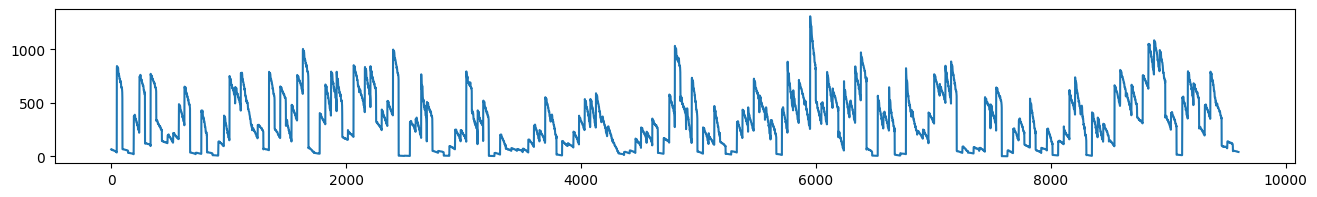

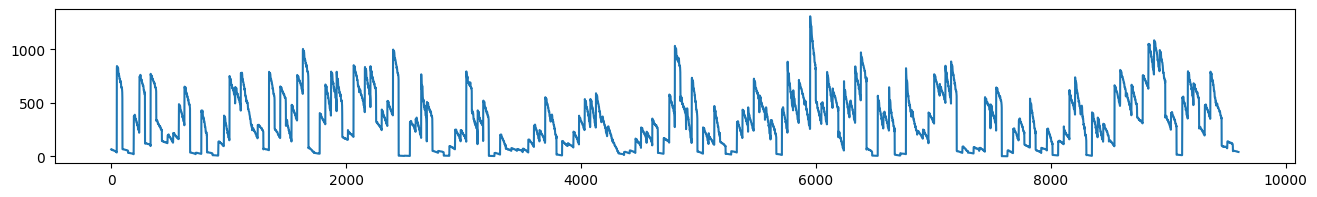

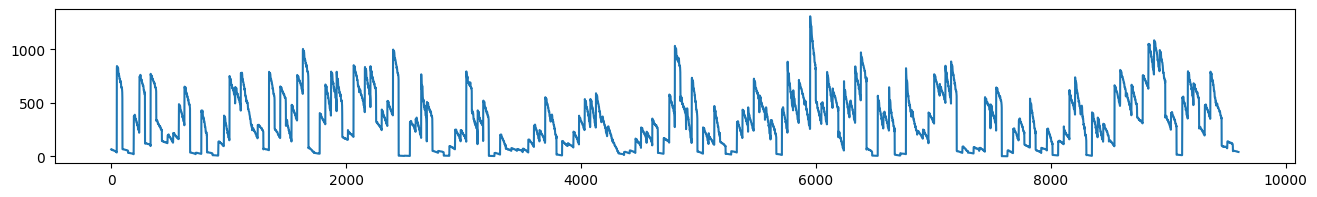

In [ ]:
%matplotlib inline
plot(test['答案'].values)
plt.show()

In [ ]:
# 紀錄參數

"""
df_parameter = pd.DataFrame({'Model':['iTransformer'], 'Task':['long_term_forecast'], 'Seq_len':[72], 'Label_len':[np.nan], 'Pred_len':[48], 'drop_out':[0.05], \
              'd_model':[64], 'n_heads':[8], 'e_layer':[3], 'd_layer':[1], 'd_ff':[64], 'Stride_ratio':[0.95], 'Valid loss(No Normaliztion)':[130000], \
              'Valid loss': [0.54], 'Upload score': [1594564], 'Sunlight':['Yes'], 'Solar_irrad':['Yes'], 'Augment':['Yes']} )
df_parameter.to_csv('parameters.csv', index=False)
"""